<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/EuroSAT_RGB_Vision_Transformer_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EuroSAT RGB Vision Transformer Research Pipeline

**Deskripsi singkat:**  
Notebook ini dirancang sebagai pipeline penelitian klasifikasi citra satelit EuroSAT RGB berbasis *Vision Transformer* dan model pembanding. Alur program disusun secara akademik, terstruktur, dan replikatif: mulai dari pemuatan dataset, penyimpanan cache, pengambilan subset stratified 10%, audit bias data, EDA, balancing, training, evaluasi, visualisasi, explainability, hingga laporan hasil otomatis.

**Prinsip integritas ilmiah:**  
1. Nilai akurasi, macro-F1, recall, precision, confusion matrix, dan hasil terbaik tidak ditulis secara manual.  
2. Semua hasil performa hanya boleh berasal dari output eksperimen.  
3. Dataset subset 10% digunakan untuk meringankan komputasi; klaim final tetap perlu validasi pada dataset penuh.  
4. Tahap evaluasi menggunakan metrik multi-aspek agar tidak bias pada accuracy saja.  
5. Kesimpulan dibatasi pada dataset, split, seed, konfigurasi model, dan parameter eksperimen yang digunakan.

**Main Program Title:** *EuroSAT RGB Vision Transformer Research Pipeline*  
**Main Output Title:** *Integrated Model Evaluation Report*

## 1. Notebook Setup and Reproducibility

Bagian ini mengatur library, seed, device, dan konfigurasi utama. Komentar kode menggunakan bahasa Indonesia agar pembaca mudah mengikuti logika program. Reproducibility dijaga melalui seed dan konfigurasi deterministik sejauh didukung oleh PyTorch.

In [12]:
# 1. Notebook Setup and Reproducibility
# Komentar berbahasa Indonesia disediakan untuk menjelaskan logika akademik setiap tahap.

# Jika dijalankan di Google Colab, aktifkan instalasi library berikut.
# Pada Jupyter lokal, baris ini dapat dilewati jika seluruh library sudah tersedia.
!pip -q install datasets timm torchmetrics scikit-learn matplotlib pandas numpy pillow captum graphviz joblib streamlit pyngrok

import os
import time
import json
import math
import random
import platform
import warnings
import datetime
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

import timm
from datasets import load_dataset, load_from_disk, DatasetDict
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42

def set_global_seed(seed: int = 42, deterministic: bool = True):
    """Mengatur seed agar eksperimen lebih replikatif."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Mode deterministik membantu mengurangi variasi hasil,
    # meskipun tidak selalu menjamin identik lintas perangkat.
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception as err:
            print("Deterministic mode warning:", err)

set_global_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = {
    "program_title": "EuroSAT RGB Vision Transformer Research Pipeline",
    "main_output_title": "Integrated Model Evaluation Report",
    "dataset_name": "timm/eurosat-rgb",
    "output_dir": "eurosat_vit_academic_outputs",
    "dataset_cache_dir": "eurosat_rgb_cached_full",
    "subset_cache_dir": "eurosat_rgb_cached_subset_10pct",
    "reuse_cached_dataset": True,
    "force_rebuild_dataset_cache": False,
    "force_rebuild_subset_cache": False,
    "use_subset": True,
    "subset_fraction": 0.10,
    "seed": SEED,
    "image_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "epochs": 8,
    "learning_rate": 3e-5,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "early_stopping_patience": 3,
    "imbalance_ratio_threshold": 1.20,
    "use_class_weighted_loss": True,
    "use_weighted_sampler_if_imbalanced": True,
    "run_training": False,
    "models": {
        "Baseline_CNN_ResNet18": "resnet18",
        "Main_ViT_Tiny": "vit_tiny_patch16_224",
        "Efficient_Transformer_MobileViT": "mobilevit_xxs"
    },
    "best_model_priority": [
        "test_macro_f1_desc",
        "test_accuracy_desc",
        "total_params_asc",
        "inference_time_ms_per_image_asc"
    ]
}

OUTPUT_DIR = Path(CFG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reproducibility_info = {
    "Program Title": CFG["program_title"],
    "Main Output Title": CFG["main_output_title"],
    "Seed": SEED,
    "Device": DEVICE,
    "Python Version": platform.python_version(),
    "Torch Version": torch.__version__,
    "CUDA Available": torch.cuda.is_available(),
    "CUDA Version": torch.version.cuda,
    "timm Version": getattr(timm, "__version__", "unknown")
}

with open(OUTPUT_DIR / "config_initial.json", "w", encoding="utf-8") as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)

print("Reproducibility Summary")
display(pd.DataFrame([reproducibility_info]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.4 MB/s eta 0:00:00
Reproducibility Summary


,Program Title,Main Output Title,Seed,Device,Python Version,Torch Version,CUDA Available,CUDA Version,timm Version
0,EuroSAT RGB Vision Transformer Research Pipeline,Integrated Model Evaluation Report,42,cuda,3.12.13,2.10.0+cu128,True,12.8,1.0.26


## 2. Literature Gap and Research Novelty

Cell ini menyusun latar belakang literatur, gap penelitian, dan novelty. Judul tabel dan output menggunakan bahasa Inggris, sedangkan penjelasan tetap menggunakan bahasa Indonesia akademik.

In [13]:
# 2. Literature Gap and Research Novelty
# Literatur digunakan sebagai dasar gap, bukan sebagai klaim hasil eksperimen baru.

literature = [
    {
        "No": 1,
        "Author_Year": "Bazi et al. (2021)",
        "Title": "Vision Transformers for Remote Sensing Image Classification",
        "Journal": "Remote Sensing",
        "DOI": "10.3390/rs13030516",
        "DOI_URL": "https://doi.org/10.3390/rs13030516",
        "Research_Gap": "ViT relevan untuk remote sensing, tetapi perlu evaluasi integratif yang mencakup baseline, efisiensi, per-class analysis, dan XAI."
    },
    {
        "No": 2,
        "Author_Year": "Hao et al. (2022)",
        "Title": "Two-Stream Swin Transformer with Differentiable Sobel Operator for Remote Sensing Image Classification",
        "Journal": "Remote Sensing",
        "DOI": "10.3390/rs14061507",
        "DOI_URL": "https://doi.org/10.3390/rs14061507",
        "Research_Gap": "Penguatan edge/Sobel menarik, tetapi perlu dibandingkan dalam pipeline yang sama dengan ViT dan CNN baseline."
    },
    {
        "No": 3,
        "Author_Year": "Zheng et al. (2023)",
        "Title": "A Lightweight Dual-Branch Swin Transformer for Remote Sensing Scene Classification",
        "Journal": "Remote Sensing",
        "DOI": "10.3390/rs15112865",
        "DOI_URL": "https://doi.org/10.3390/rs15112865",
        "Research_Gap": "Model lightweight perlu dievaluasi bersama aspek bias data, reproducibility, dan efisiensi inferensi."
    },
    {
        "No": 4,
        "Author_Year": "Rozario et al. (2024)",
        "Title": "Optimizing Mobile Vision Transformers for Land Cover Classification",
        "Journal": "Applied Sciences",
        "DOI": "10.3390/app14135920",
        "DOI_URL": "https://doi.org/10.3390/app14135920",
        "Research_Gap": "Efisiensi MobileViT relevan, tetapi perlu digabungkan dengan macro-F1, confusion matrix, dan XAI."
    },
    {
        "No": 5,
        "Author_Year": "Khan et al. (2024)",
        "Title": "Transformer-based land use and land cover classification with explainability using satellite imagery",
        "Journal": "Scientific Reports",
        "DOI": "10.1038/s41598-024-67186-4",
        "DOI_URL": "https://doi.org/10.1038/s41598-024-67186-4",
        "Research_Gap": "Explainability penting, tetapi penelitian ini memperluasnya melalui audit data, balancing, baseline, efisiensi, dan reproducibility."
    }
]

literature_df = pd.DataFrame(literature)
pd.set_option("display.max_colwidth", 170)

print("Literature Gap Matrix")
display(literature_df)

novelty_statement = (
    "Novelty: an integrated evaluation pipeline for EuroSAT RGB classification that combines "
    "data bias auditing, stratified 10% subset sampling, reproducibility control, CNN baseline, "
    "pretrained Vision Transformer, efficient Transformer, macro-F1, confusion matrix, computational "
    "efficiency analysis, and explainability."
)

print("Research Novelty Statement")
print(novelty_statement)

literature_df.to_csv(OUTPUT_DIR / "literature_gap_matrix.csv", index=False)
with open(OUTPUT_DIR / "novelty_statement.txt", "w", encoding="utf-8") as f:
    f.write(novelty_statement)

Literature Gap Matrix


,No,Author_Year,Title,Journal,DOI,DOI_URL,Research_Gap
0,1,Bazi et al. (2021),Vision Transformers for Remote Sensing Image Classification,Remote Sensing,10.3390/rs13030516,https://doi.org/10.3390/rs13030516,"ViT relevan untuk remote sensing, tetapi perlu evaluasi integratif yang mencakup baseline, efisiensi, per-class analysis, dan XAI."
1,2,Hao et al. (2022),Two-Stream Swin Transformer with Differentiable Sobel Operator for Remote Sensing Image Classification,Remote Sensing,10.3390/rs14061507,https://doi.org/10.3390/rs14061507,"Penguatan edge/Sobel menarik, tetapi perlu dibandingkan dalam pipeline yang sama dengan ViT dan CNN baseline."
2,3,Zheng et al. (2023),A Lightweight Dual-Branch Swin Transformer for Remote Sensing Scene Classification,Remote Sensing,10.3390/rs15112865,https://doi.org/10.3390/rs15112865,"Model lightweight perlu dievaluasi bersama aspek bias data, reproducibility, dan efisiensi inferensi."
3,4,Rozario et al. (2024),Optimizing Mobile Vision Transformers for Land Cover Classification,Applied Sciences,10.3390/app14135920,https://doi.org/10.3390/app14135920,"Efisiensi MobileViT relevan, tetapi perlu digabungkan dengan macro-F1, confusion matrix, dan XAI."
4,5,Khan et al. (2024),Transformer-based land use and land cover classification with explainability using satellite imagery,Scientific Reports,10.1038/s41598-024-67186-4,https://doi.org/10.1038/s41598-024-67186-4,"Explainability penting, tetapi penelitian ini memperluasnya melalui audit data, balancing, baseline, efisiensi, dan reproducibility."


Research Novelty Statement
Novelty: an integrated evaluation pipeline for EuroSAT RGB classification that combines data bias auditing, stratified 10% subset sampling, reproducibility control, CNN baseline, pretrained Vision Transformer, efficient Transformer, macro-F1, confusion matrix, computational efficiency analysis, and explainability.


## 3. Dataset Loading, Local Caching, and 10% Stratified Sampling

Cell ini menggabungkan proses load dataset, cache lokal, dan subset 10% dalam satu tahap yang efisien. Tujuannya agar dataset tidak diunduh atau diproses berulang-ulang saat notebook dijalankan kembali.

In [14]:
# 3. Dataset Loading, Local Caching, and 10% Stratified Sampling
# Strategi ini menjaga efisiensi komputasi tanpa menghilangkan kontrol proporsi label.

FULL_CACHE_DIR = Path(CFG["dataset_cache_dir"])
SUBSET_CACHE_DIR = Path(CFG["subset_cache_dir"])

def ensure_three_splits(dataset):
    """Memastikan dataset memiliki train, validation, dan test split."""
    available = list(dataset.keys())

    if all(k in available for k in ["train", "validation", "test"]):
        return dataset, "Dataset already has train/validation/test splits."

    # Jika split tidak lengkap, program membuat split stratified agar proporsi kelas tetap terkendali.
    base_key = "train" if "train" in available else available[0]
    base = dataset[base_key]

    temp = base.train_test_split(
        test_size=0.30,
        seed=CFG["seed"],
        stratify_by_column="label"
    )
    val_test = temp["test"].train_test_split(
        test_size=0.50,
        seed=CFG["seed"],
        stratify_by_column="label"
    )

    ds_three = DatasetDict({
        "train": temp["train"],
        "validation": val_test["train"],
        "test": val_test["test"]
    })

    return ds_three, "Created stratified 70/15/15 train/validation/test splits."

def load_or_cache_full_dataset():
    """Memuat dataset penuh dari cache lokal atau Hugging Face Hub."""
    if (
        CFG["reuse_cached_dataset"]
        and FULL_CACHE_DIR.exists()
        and not CFG["force_rebuild_dataset_cache"]
    ):
        print(f"Loading Full Dataset from Local Cache: {FULL_CACHE_DIR}")
        return load_from_disk(str(FULL_CACHE_DIR)), "loaded_full_from_disk"

    print(f"Downloading Full Dataset from Hugging Face: {CFG['dataset_name']}")
    dataset = load_dataset(CFG["dataset_name"])
    dataset, split_note = ensure_three_splits(dataset)

    print(f"Saving Full Dataset to Local Cache: {FULL_CACHE_DIR}")
    dataset.save_to_disk(str(FULL_CACHE_DIR))
    return dataset, f"downloaded_full_and_cached | {split_note}"

def make_stratified_subset(dataset, fraction=0.10):
    """Membuat subset stratified dari setiap split tanpa mencampur train, validation, dan test."""
    if not (0 < fraction <= 1):
        raise ValueError("subset_fraction harus berada pada rentang 0 < fraction <= 1.")

    if fraction >= 1:
        return dataset

    subset_splits = {}

    for split_name in dataset.keys():
        split_data = dataset[split_name]
        n_before = len(split_data)

        sampled = split_data.train_test_split(
            train_size=fraction,
            seed=CFG["seed"],
            stratify_by_column="label"
        )["train"]

        subset_splits[split_name] = sampled
        print(f"{split_name}: {len(sampled)} / {n_before} samples ({fraction:.0%})")

    return DatasetDict(subset_splits)

def load_or_create_subset_dataset(full_dataset):
    """Memuat subset 10% dari cache lokal atau membuatnya jika belum tersedia."""
    if not CFG["use_subset"]:
        print("Using Full Dataset")
        return full_dataset, "using_full_dataset"

    if (
        CFG["reuse_cached_dataset"]
        and SUBSET_CACHE_DIR.exists()
        and not CFG["force_rebuild_subset_cache"]
    ):
        print(f"Loading 10% Stratified Subset from Local Cache: {SUBSET_CACHE_DIR}")
        return load_from_disk(str(SUBSET_CACHE_DIR)), "loaded_subset_from_disk"

    print(f"Creating 10% Stratified Subset: {CFG['subset_fraction']:.0%} of each split.")
    subset = make_stratified_subset(full_dataset, fraction=CFG["subset_fraction"])

    print(f"Saving 10% Stratified Subset to Local Cache: {SUBSET_CACHE_DIR}")
    subset.save_to_disk(str(SUBSET_CACHE_DIR))
    return subset, "created_subset_and_cached"

full_ds, full_load_status = load_or_cache_full_dataset()
ds, subset_load_status = load_or_create_subset_dataset(full_ds)

dataset_load_report = {
    "Full Dataset Status": full_load_status,
    "Active Dataset Status": subset_load_status,
    "Use Subset": CFG["use_subset"],
    "Subset Fraction": CFG["subset_fraction"],
    "Active Dataset Rows": {split: len(ds[split]) for split in ds.keys()}
}

print("Dataset Loading Report")
display(pd.DataFrame([dataset_load_report]))

with open(OUTPUT_DIR / "dataset_loading_report.json", "w", encoding="utf-8") as f:
    json.dump(dataset_load_report, f, indent=2, ensure_ascii=False)

print(ds)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/55.3M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/18.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/540 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/540 [00:00<?, ? examples/s]

Dataset Loading Report


,Full Dataset Status,Active Dataset Status,Use Subset,Subset Fraction,Active Dataset Rows
0,downloaded_full_and_cached | Dataset already has train/validation/test splits.,created_subset_and_cached,True,0.1,"{'train': 1620, 'validation': 540, 'test': 540}"


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 1620
    })
    validation: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 540
    })
    test: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 540
    })
})


## 4. Data Audit and Bias Screening

Cell ini mengaudit struktur dataset, distribusi kelas, dan potensi imbalance. Hasil audit menjadi dasar apakah balancing perlu diaktifkan.

In [15]:
# 4. Data Audit and Bias Screening
# Audit dilakukan sebelum preprocessing agar potensi masalah data tidak tersembunyi oleh proses modeling.

def get_label_names(dataset):
    """Mengambil nama label resmi dari metadata dataset."""
    first_split = list(dataset.keys())[0]
    label_feature = dataset[first_split].features["label"]
    if hasattr(label_feature, "names"):
        return list(label_feature.names)
    labels = sorted(set(dataset[first_split]["label"]))
    return [str(x) for x in labels]

label_names = get_label_names(ds)
num_classes = len(label_names)

def audit_split(dataset, split_name):
    """Menghitung ringkasan distribusi label untuk setiap split."""
    split = dataset[split_name]
    labels = list(split["label"])
    counts = pd.Series(labels).value_counts().sort_index()

    distribution = pd.DataFrame({
        "Label ID": counts.index.astype(int),
        "Class Name": [label_names[int(i)] for i in counts.index],
        "Count": counts.values
    })

    min_count = int(distribution["Count"].min())
    max_count = int(distribution["Count"].max())
    imbalance_ratio = max_count / max(min_count, 1)

    missing_label = sum(x is None for x in labels)
    missing_image_checked = sum(split[i].get("image") is None for i in range(min(100, len(split))))

    summary = {
        "Split": split_name,
        "Samples": len(split),
        "Classes Found": int(distribution.shape[0]),
        "Minimum Class Count": min_count,
        "Maximum Class Count": max_count,
        "Imbalance Ratio": float(imbalance_ratio),
        "Imbalanced": bool(imbalance_ratio >= CFG["imbalance_ratio_threshold"]),
        "Missing Labels": int(missing_label),
        "Missing Images Checked First 100": int(missing_image_checked)
    }

    return summary, distribution

audit_rows = []
distribution_tables = {}

for split in ds.keys():
    summary, table = audit_split(ds, split)
    audit_rows.append(summary)
    distribution_tables[split] = table

audit_df = pd.DataFrame(audit_rows)

print("Data Audit Summary")
display(audit_df)

for split, table in distribution_tables.items():
    print(f"Class Distribution Table - {split}")
    display(table)

audit_df.to_csv(OUTPUT_DIR / "data_audit_summary.csv", index=False)

Data Audit Summary


,Split,Samples,Classes Found,Minimum Class Count,Maximum Class Count,Imbalance Ratio,Imbalanced,Missing Labels,Missing Images Checked First 100
0,train,1620,10,120,186,1.550000,True,0,0
1,validation,540,10,41,63,1.536585,True,0,0
2,test,540,10,40,61,1.525000,True,0,0


Class Distribution Table - train


,Label ID,Class Name,Count
0,0,AnnualCrop,179
1,1,Forest,179
2,2,HerbaceousVegetation,180
3,3,Highway,150
4,4,Industrial,149
5,5,Pasture,120
6,6,PermanentCrop,148
7,7,Residential,186
8,8,River,146
9,9,SeaLake,183


Class Distribution Table - validation


,Label ID,Class Name,Count
0,0,AnnualCrop,61
1,1,Forest,61
2,2,HerbaceousVegetation,63
3,3,Highway,50
4,4,Industrial,51
5,5,Pasture,41
6,6,PermanentCrop,48
7,7,Residential,58
8,8,River,51
9,9,SeaLake,56


Class Distribution Table - test


,Label ID,Class Name,Count
0,0,AnnualCrop,60
1,1,Forest,61
2,2,HerbaceousVegetation,57
3,3,Highway,49
4,4,Industrial,50
5,5,Pasture,40
6,6,PermanentCrop,54
7,7,Residential,55
8,8,River,53
9,9,SeaLake,61


## 5. Exploratory Data Analysis Outputs

Cell ini menghasilkan visualisasi EDA: distribusi kelas, contoh citra per kelas, dan statistik RGB. Judul output memakai bahasa Inggris agar siap dimasukkan dalam laporan internasional.

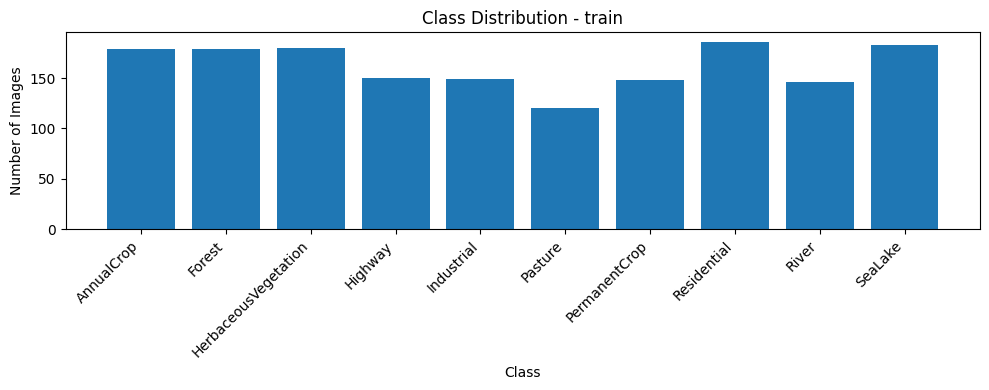

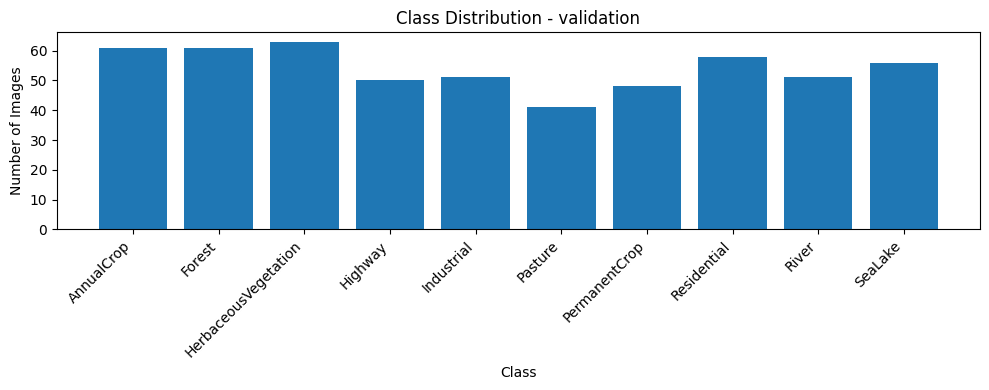

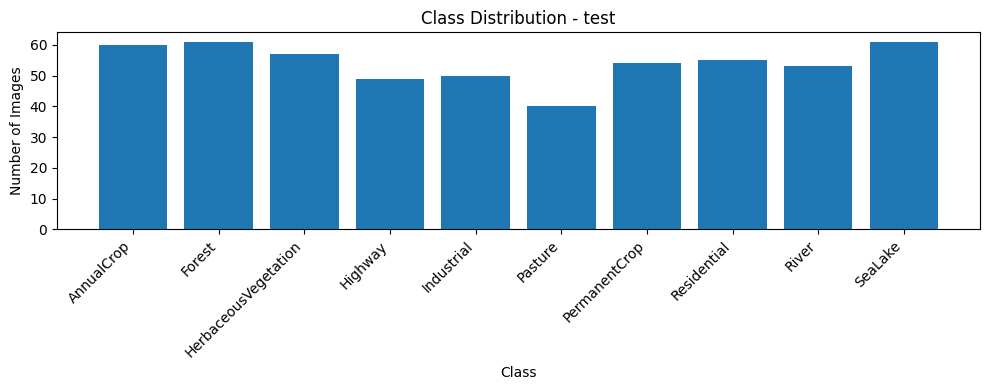

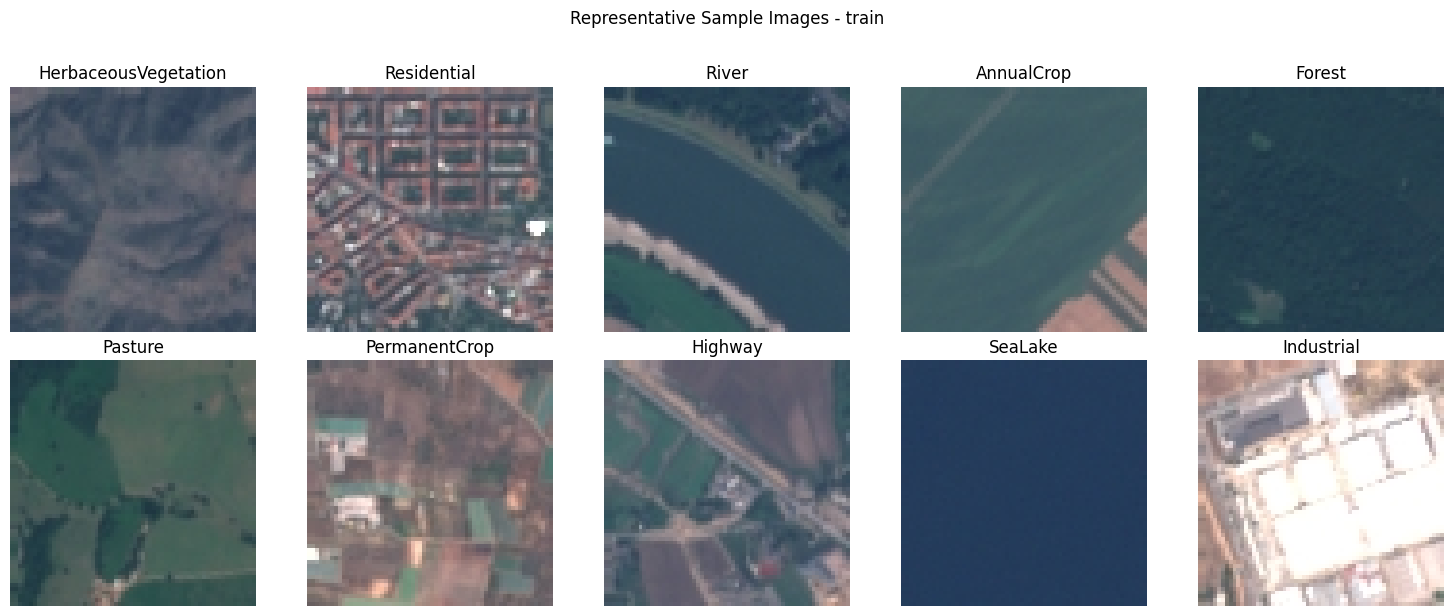

RGB Statistical Profile by Class


,Label ID,Class Name,R Mean,G Mean,B Mean,R Std,G Std,B Std
0,0,AnnualCrop,0.507148,0.468948,0.459842,0.152240,0.078956,0.063450
1,1,Forest,0.155231,0.255589,0.297311,0.016900,0.016656,0.011224
2,2,HerbaceousVegetation,0.389386,0.391009,0.409966,0.080127,0.058790,0.047843
3,3,Highway,0.355561,0.383745,0.410768,0.109737,0.075054,0.064608
4,4,Industrial,0.480104,0.488570,0.521866,0.185221,0.157294,0.148016
5,5,Pasture,0.246942,0.345641,0.363455,0.055791,0.034717,0.027170
6,6,PermanentCrop,0.476086,0.449727,0.441774,0.115970,0.077274,0.061492
7,7,Residential,0.399005,0.411869,0.443353,0.100019,0.077005,0.072797
8,8,River,0.259516,0.336180,0.373524,0.097656,0.071194,0.055538
9,9,SeaLake,0.183569,0.281788,0.345726,0.012643,0.011163,0.008943


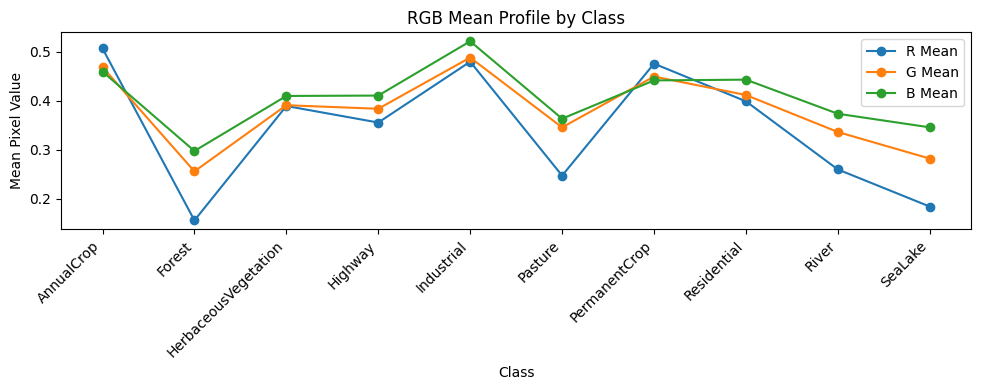

In [17]:
# 5. Exploratory Data Analysis Outputs
# EDA membantu memahami karakter data sebelum model dilatih.

def plot_class_distribution(distribution_tables):
    """Membuat grafik distribusi kelas untuk setiap split."""
    for split, table in distribution_tables.items():
        plt.figure(figsize=(10, 4))
        plt.bar(table["Class Name"], table["Count"])
        plt.title(f"Class Distribution - {split}")
        plt.xlabel("Class")
        plt.ylabel("Number of Images")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"class_distribution_{split}.png", dpi=150)
        plt.show()

def show_sample_images(dataset, split="train", max_classes=10):
    """Menampilkan satu contoh citra dari setiap kelas."""
    data = dataset[split]
    seen = set()
    samples = []

    for idx in range(len(data)):
        item = data[idx]
        label = int(item["label"])
        if label not in seen:
            seen.add(label)
            samples.append(item)
        if len(samples) >= min(max_classes, num_classes):
            break

    cols = 5
    rows = math.ceil(len(samples) / cols)
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, item in enumerate(samples):
        img = item["image"].convert("RGB")
        label = int(item["label"])
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(label_names[label])
        plt.axis("off")

    plt.suptitle(f"Representative Sample Images - {split}", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"representative_sample_images_{split}.png", dpi=150)
    plt.show()

def compute_rgb_stats(dataset, split="train", max_per_class=150):
    """Menghitung statistik RGB rata-rata per kelas sebagai EDA visual sederhana."""
    records = []
    counters = {i: 0 for i in range(num_classes)}

    for item in dataset[split]:
        label = int(item["label"])
        if counters[label] >= max_per_class:
            continue

        img = np.asarray(item["image"].convert("RGB")).astype(np.float32) / 255.0
        records.append({
            "Label ID": label,
            "Class Name": label_names[label],
            "R Mean": float(img[:, :, 0].mean()),
            "G Mean": float(img[:, :, 1].mean()),
            "B Mean": float(img[:, :, 2].mean()),
            "R Std": float(img[:, :, 0].std()),
            "G Std": float(img[:, :, 1].std()),
            "B Std": float(img[:, :, 2].std())
        })
        counters[label] += 1

        if all(v >= max_per_class for v in counters.values()):
            break

    return pd.DataFrame(records).groupby(["Label ID", "Class Name"]).mean().reset_index()

plot_class_distribution(distribution_tables)
show_sample_images(ds, split="train")

rgb_stats_df = compute_rgb_stats(ds, split="train", max_per_class=150)

print("RGB Statistical Profile by Class")
display(rgb_stats_df)

plt.figure(figsize=(10, 4))
x = np.arange(len(rgb_stats_df))
plt.plot(x, rgb_stats_df["R Mean"], marker="o", label="R Mean")
plt.plot(x, rgb_stats_df["G Mean"], marker="o", label="G Mean")
plt.plot(x, rgb_stats_df["B Mean"], marker="o", label="B Mean")
plt.xticks(x, rgb_stats_df["Class Name"], rotation=45, ha="right")
plt.title("RGB Mean Profile by Class")
plt.xlabel("Class")
plt.ylabel("Mean Pixel Value")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rgb_mean_profile_by_class.png", dpi=150)
plt.show()

rgb_stats_df.to_csv(OUTPUT_DIR / "rgb_statistical_profile_by_class.csv", index=False)

## 6. Preprocessing, Balancing Strategy, and DataLoaders

Cell ini menggabungkan preprocessing, balancing, dan DataLoader. Augmentasi hanya diterapkan pada train set untuk mencegah bias evaluasi. Weighted sampler dan class-weighted loss digunakan secara adaptif jika train split imbalanced.

In [18]:
# 6. Preprocessing, Balancing Strategy, and DataLoaders
# Bagian ini mencegah data leakage dan menjaga konsistensi preprocessing antar model.

IMAGE_SIZE = CFG["image_size"]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

def transform_train(batch):
    """Transformasi train dengan augmentasi ringan."""
    batch["pixel_values"] = [train_transform(img.convert("RGB")) for img in batch["image"]]
    return batch

def transform_eval(batch):
    """Transformasi validation/test tanpa augmentasi acak."""
    batch["pixel_values"] = [eval_transform(img.convert("RGB")) for img in batch["image"]]
    return batch

ds_work = ds

train_ds = ds_work["train"].with_transform(transform_train)
val_ds = ds_work["validation"].with_transform(transform_eval)
test_ds = ds_work["test"].with_transform(transform_eval)

train_labels = np.array(ds_work["train"]["label"])
train_counts = np.bincount(train_labels, minlength=num_classes)
train_min = train_counts.min()
train_max = train_counts.max()
train_imbalance_ratio = train_max / max(train_min, 1)

class_weights = train_counts.sum() / (num_classes * np.maximum(train_counts, 1))
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

is_train_imbalanced = train_imbalance_ratio >= CFG["imbalance_ratio_threshold"]

sampler = None
shuffle_train = True

if CFG["use_weighted_sampler_if_imbalanced"] and is_train_imbalanced:
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    shuffle_train = False

balance_report = {
    "Train Minimum Class Count": int(train_min),
    "Train Maximum Class Count": int(train_max),
    "Train Imbalance Ratio": float(train_imbalance_ratio),
    "Imbalance Threshold": CFG["imbalance_ratio_threshold"],
    "Weighted Sampler Active": bool(sampler is not None),
    "Class Weighted Loss Active": bool(CFG["use_class_weighted_loss"])
}

print("Balancing Strategy Report")
display(pd.DataFrame([balance_report]))

display(pd.DataFrame({
    "Class Name": label_names,
    "Count": train_counts,
    "Class Weight": class_weights
}))

def collate_fn(batch):
    """Menyusun batch tensor untuk model PyTorch."""
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=shuffle_train,
    sampler=sampler,
    num_workers=CFG["num_workers"],
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

batch = next(iter(train_loader))

print("DataLoader Sanity Check")
print("Pixel Values Shape:", tuple(batch["pixel_values"].shape))
print("Labels Shape:", tuple(batch["labels"].shape))
print("Labels Dtype:", batch["labels"].dtype)

with open(OUTPUT_DIR / "balance_report.json", "w", encoding="utf-8") as f:
    json.dump(balance_report, f, indent=2, ensure_ascii=False)

Balancing Strategy Report


,Train Minimum Class Count,Train Maximum Class Count,Train Imbalance Ratio,Imbalance Threshold,Weighted Sampler Active,Class Weighted Loss Active
0,120,186,1.55,1.2,True,True


,Class Name,Count,Class Weight
0,AnnualCrop,179,0.888353
1,Forest,179,0.888353
2,HerbaceousVegetation,180,0.883418
3,Highway,150,1.060102
4,Industrial,149,1.067217
5,Pasture,120,1.325127
6,PermanentCrop,148,1.074427
7,Residential,186,0.854921
8,River,146,1.089146
9,SeaLake,183,0.868936


DataLoader Sanity Check
Pixel Values Shape: (32, 3, 224, 224)
Labels Shape: (32,)
Labels Dtype: torch.int64


## 7. Model Definition and Experiment Protocol

Cell ini mendefinisikan tiga kelompok model: CNN baseline, ViT sebagai model utama, dan Transformer efisien. Semua model diarahkan ke jumlah kelas yang sama agar perbandingan adil.

In [19]:
# 7. Model Definition and Experiment Protocol
# Model dibuat melalui timm.create_model agar konfigurasi classifier dapat disesuaikan dengan 10 kelas.

def build_model(model_name: str, num_classes: int, pretrained: bool = True):
    """Membangun model dan mengganti classifier head sesuai jumlah kelas dataset."""
    try:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
        pretrained_status = pretrained
    except Exception as err:
        print(f"Warning: pretrained weights failed for {model_name}. Using pretrained=False. Error: {err}")
        model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
        pretrained_status = False
    return model.to(DEVICE), pretrained_status

def count_parameters(model):
    """Menghitung jumlah parameter total dan trainable."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(total), int(trainable)

model_inventory = []

for model_key, model_name in CFG["models"].items():
    try:
        temp_model, pretrained_status = build_model(model_name, num_classes, pretrained=True)
        total_params, trainable_params = count_parameters(temp_model)
        model_inventory.append({
            "Model Key": model_key,
            "Model Name": model_name,
            "Pretrained Loaded": pretrained_status,
            "Total Parameters": total_params,
            "Trainable Parameters": trainable_params
        })
        del temp_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception as err:
        model_inventory.append({
            "Model Key": model_key,
            "Model Name": model_name,
            "Pretrained Loaded": False,
            "Total Parameters": None,
            "Trainable Parameters": None,
            "Error": str(err)
        })

model_inventory_df = pd.DataFrame(model_inventory)

print("Model Inventory")
display(model_inventory_df)

model_inventory_df.to_csv(OUTPUT_DIR / "model_inventory.csv", index=False)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.14M [00:00<?, ?B/s]

Model Inventory


,Model Key,Model Name,Pretrained Loaded,Total Parameters,Trainable Parameters
0,Baseline_CNN_ResNet18,resnet18,True,11181642,11181642
1,Main_ViT_Tiny,vit_tiny_patch16_224,True,5526346,5526346
2,Efficient_Transformer_MobileViT,mobilevit_xxs,True,954234,954234


In [24]:
CFG["run_training"] = True

## 8. Training, Evaluation, and Fit Diagnosis

Cell ini menggabungkan fungsi training, evaluasi, early stopping, diagnosis underfitting/overfitting, dan eksekusi eksperimen. Secara default training tidak dijalankan agar tidak menghasilkan klaim performa palsu.

In [25]:
all_results = []
all_histories = {}
trained_models = {}
test_artifacts = {}

if CFG["run_training"]:
    for model_key, model_name in CFG["models"].items():
        print("\n" + "=" * 90)
        print(f"Running Model: {model_key} | {model_name}")

        model, pretrained_loaded = build_model(model_name, num_classes, pretrained=True)
        total_params, trainable_params = count_parameters(model)

        model, history_df = fit_model(model, train_loader, val_loader, model_key)
        diagnosis = diagnose_fit(history_df)

        val_eval = evaluate(model, val_loader)
        test_eval = evaluate(model, test_loader)
        inference_ms = measure_inference_time(model, test_loader)

        row = {
            "Model Key": model_key,
            "Model Name": model_name,
            "Pretrained Loaded": pretrained_loaded,
            "Validation Accuracy": val_eval["accuracy"],
            "Validation Macro F1": val_eval["macro_f1"],
            "Test Accuracy": test_eval["accuracy"],
            "Test Macro Precision": test_eval["macro_precision"],
            "Test Macro Recall": test_eval["macro_recall"],
            "Test Macro F1": test_eval["macro_f1"],
            "Total Parameters": total_params,
            "Trainable Parameters": trainable_params,
            "Inference Time ms per Image": inference_ms,
            "Fit Status": diagnosis["Fit Status"],
            "Fit Diagnosis": diagnosis["Fit Diagnosis"],
            "Fit Recommendation": diagnosis["Fit Recommendation"]
        }

        all_results.append(row)
        all_histories[model_key] = history_df
        trained_models[model_key] = model
        test_artifacts[model_key] = test_eval

        history_df.to_csv(
            OUTPUT_DIR / f"history_{model_key}.csv",
            index=False
        )

        test_eval["report_df"].to_csv(
            OUTPUT_DIR / f"classification_report_{model_key}.csv",
            index=False
        )

    results_df = pd.DataFrame(all_results)

else:
    print("Training has not been executed. Set CFG['run_training'] = True to run the experiment.")

    results_df = pd.DataFrame(columns=[
        "Model Key",
        "Model Name",
        "Pretrained Loaded",
        "Validation Accuracy",
        "Validation Macro F1",
        "Test Accuracy",
        "Test Macro Precision",
        "Test Macro Recall",
        "Test Macro F1",
        "Total Parameters",
        "Trainable Parameters",
        "Inference Time ms per Image",
        "Fit Status",
        "Fit Diagnosis",
        "Fit Recommendation"
    ])

print("Experiment Results Table")
display(results_df)

results_df.to_csv(
    OUTPUT_DIR / "experiment_results_table.csv",
    index=False
)


Running Model: Baseline_CNN_ResNet18 | resnet18
{'Model Key': 'Baseline_CNN_ResNet18', 'Epoch': 1, 'Train Loss': 2.2593911488850913, 'Train Accuracy': 0.1537037037037037, 'Validation Loss': 2.2371047384598675, 'Validation Accuracy': 0.21296296296296297, 'Validation Macro Precision': 0.2979991934828208, 'Validation Macro Recall': 0.23028146766020724, 'Validation Macro F1': 0.17294070009825338}
{'Model Key': 'Baseline_CNN_ResNet18', 'Epoch': 2, 'Train Loss': 2.18732045211044, 'Train Accuracy': 0.2006172839506173, 'Validation Loss': 2.170630188549266, 'Validation Accuracy': 0.2796296296296296, 'Validation Macro Precision': 0.3377794141832711, 'Validation Macro Recall': 0.3012764963527451, 'Validation Macro F1': 0.22946556463096793}
{'Model Key': 'Baseline_CNN_ResNet18', 'Epoch': 3, 'Train Loss': 2.093904228771434, 'Train Accuracy': 0.3080246913580247, 'Validation Loss': 2.087147586485919, 'Validation Accuracy': 0.3314814814814815, 'Validation Macro Precision': 0.4129112186495728, 'Valida

,Model Key,Model Name,Pretrained Loaded,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Total Parameters,Trainable Parameters,Inference Time ms per Image,Fit Status,Fit Diagnosis,Fit Recommendation
0,Baseline_CNN_ResNet18,resnet18,True,0.637037,0.609760,0.672222,0.711668,0.678838,0.645917,11181642,11181642,3.900085,underfitting_risk,Train and validation accuracy are both low with a small gap.,"Increase epochs moderately, tune learning rate, or inspect preprocessing."
1,Main_ViT_Tiny,vit_tiny_patch16_224,True,0.944444,0.942942,0.944444,0.943992,0.945008,0.943277,5526346,5526346,3.496245,fit_reasonable,No strong underfitting or overfitting indication from current heuristics.,Continue with test evaluation and per-class error analysis.
2,Efficient_Transformer_MobileViT,mobilevit_xxs,True,0.814815,0.804416,0.835185,0.843834,0.837632,0.825697,954234,954234,3.192825,fit_reasonable,No strong underfitting or overfitting indication from current heuristics.,Continue with test evaluation and per-class error analysis.


## 9. Model Ranking and Comparative Outputs

Cell ini memilih model terbaik berdasarkan urutan logis: macro-F1, accuracy, parameter, dan waktu inferensi. Jika training belum dijalankan, tidak ada klaim model terbaik.

Best Model Selection
Best Model: Main_ViT_Tiny
Ranked Model Comparison Table


,Model Key,Model Name,Pretrained Loaded,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Total Parameters,Trainable Parameters,Inference Time ms per Image,Fit Status,Fit Diagnosis,Fit Recommendation
0,Main_ViT_Tiny,vit_tiny_patch16_224,True,0.944444,0.942942,0.944444,0.943992,0.945008,0.943277,5526346,5526346,3.496245,fit_reasonable,No strong underfitting or overfitting indication from current heuristics.,Continue with test evaluation and per-class error analysis.
1,Efficient_Transformer_MobileViT,mobilevit_xxs,True,0.814815,0.804416,0.835185,0.843834,0.837632,0.825697,954234,954234,3.192825,fit_reasonable,No strong underfitting or overfitting indication from current heuristics.,Continue with test evaluation and per-class error analysis.
2,Baseline_CNN_ResNet18,resnet18,True,0.637037,0.609760,0.672222,0.711668,0.678838,0.645917,11181642,11181642,3.900085,underfitting_risk,Train and validation accuracy are both low with a small gap.,"Increase epochs moderately, tune learning rate, or inspect preprocessing."


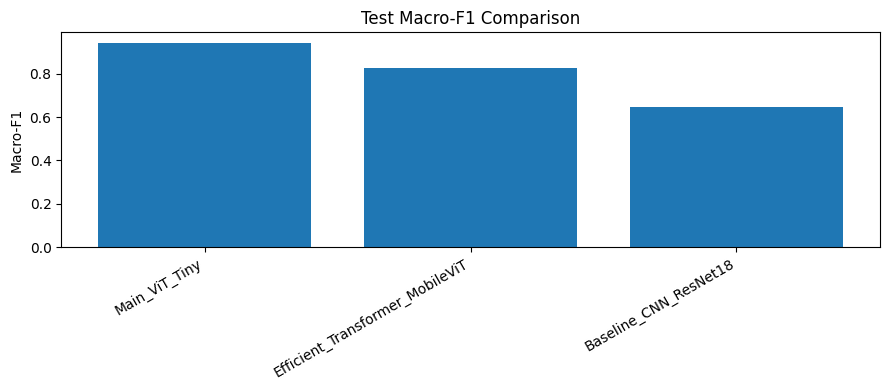

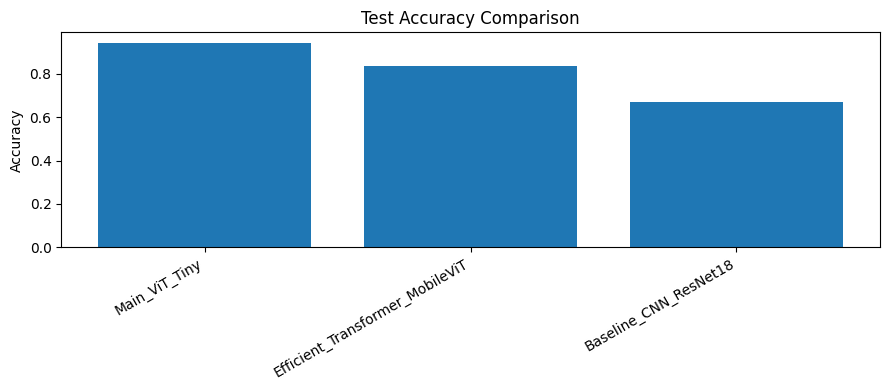

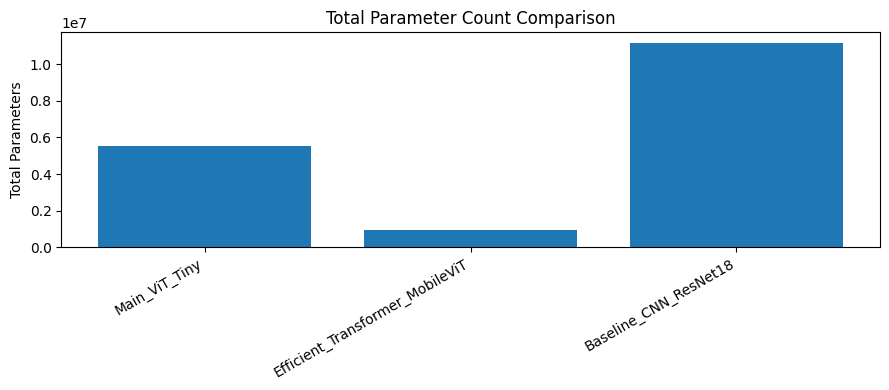

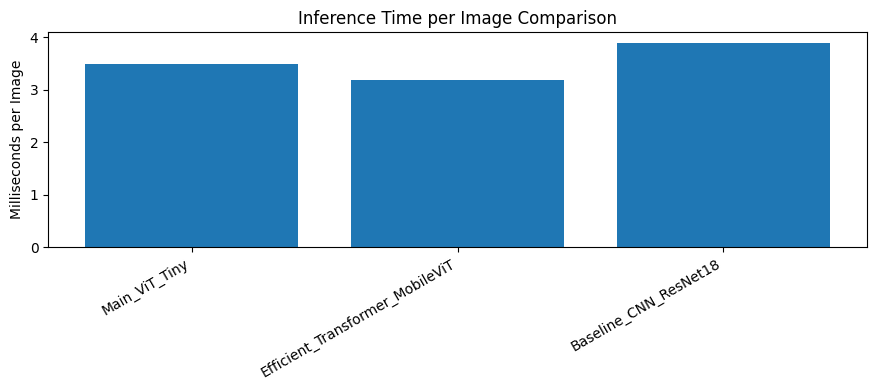

In [26]:
# 9. Model Ranking and Comparative Outputs
# Ranking dilakukan secara otomatis agar tidak ada pemilihan model subjektif.

def rank_results(results_df):
    """Mengurutkan model berdasarkan performa dan efisiensi."""
    if results_df.empty:
        return results_df, None

    ranked = results_df.sort_values(
        by=["Test Macro F1", "Test Accuracy", "Total Parameters", "Inference Time ms per Image"],
        ascending=[False, False, True, True]
    ).reset_index(drop=True)

    best = ranked.iloc[0].to_dict()
    return ranked, best

ranked_results_df, best_model = rank_results(results_df)

if best_model is None:
    print("Best Model Selection")
    print("No best model is selected because training has not been executed.")
else:
    print("Best Model Selection")
    print(f"Best Model: {best_model['Model Key']}")

print("Ranked Model Comparison Table")
display(ranked_results_df)

ranked_results_df.to_csv(OUTPUT_DIR / "ranked_model_comparison_table.csv", index=False)

def plot_model_comparison(results_df):
    """Membuat grafik perbandingan model setelah training selesai."""
    if results_df.empty:
        print("Model comparison plots are not available because training has not been executed.")
        return

    plot_df = results_df.copy().sort_values("Test Macro F1", ascending=False)

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["Model Key"], plot_df["Test Macro F1"])
    plt.title("Test Macro-F1 Comparison")
    plt.ylabel("Macro-F1")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "test_macro_f1_comparison.png", dpi=150)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["Model Key"], plot_df["Test Accuracy"])
    plt.title("Test Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "test_accuracy_comparison.png", dpi=150)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["Model Key"], plot_df["Total Parameters"])
    plt.title("Total Parameter Count Comparison")
    plt.ylabel("Total Parameters")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "total_parameter_count_comparison.png", dpi=150)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["Model Key"], plot_df["Inference Time ms per Image"])
    plt.title("Inference Time per Image Comparison")
    plt.ylabel("Milliseconds per Image")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "inference_time_per_image_comparison.png", dpi=150)
    plt.show()

plot_model_comparison(results_df)

## 10. Learning Curves and Error Analysis Outputs

Cell ini menghasilkan learning curve, confusion matrix, dan per-class recall. Visualisasi ini membantu membaca underfitting, overfitting, dan kesalahan klasifikasi antar kelas.

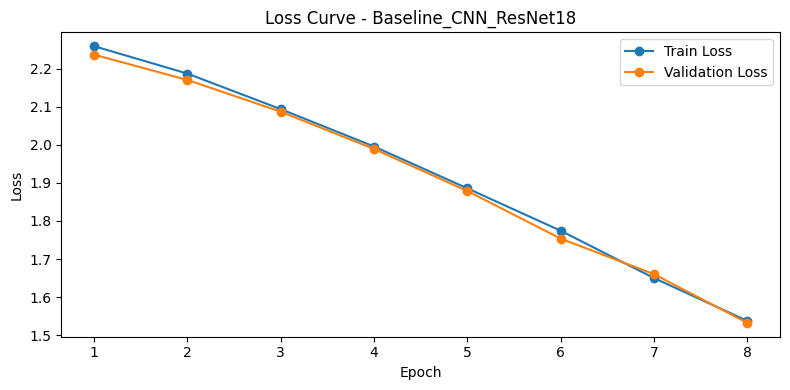

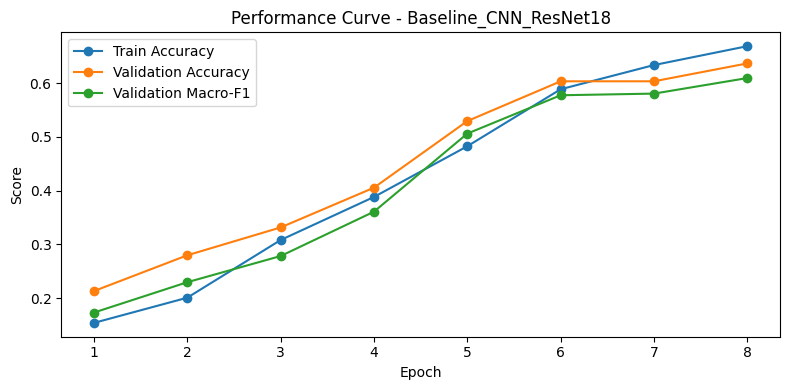

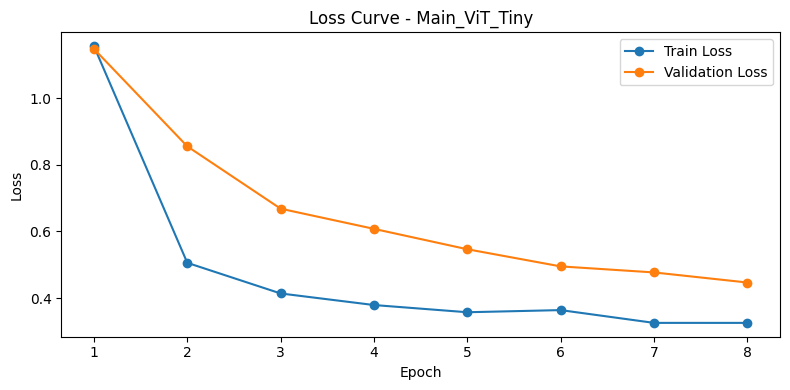

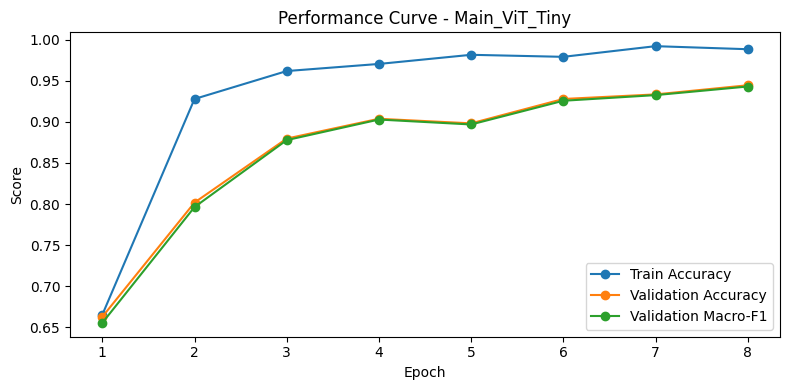

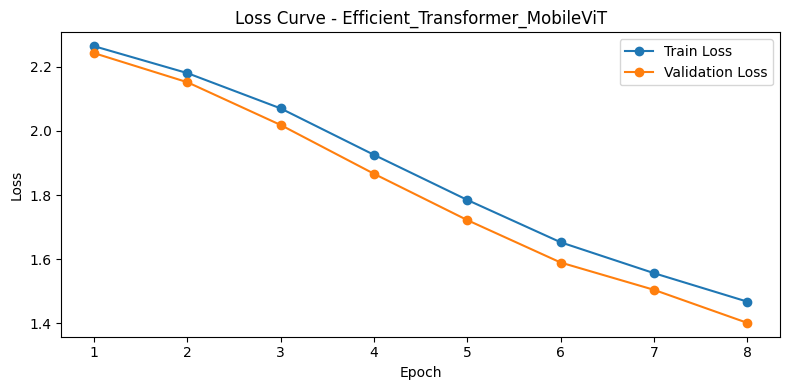

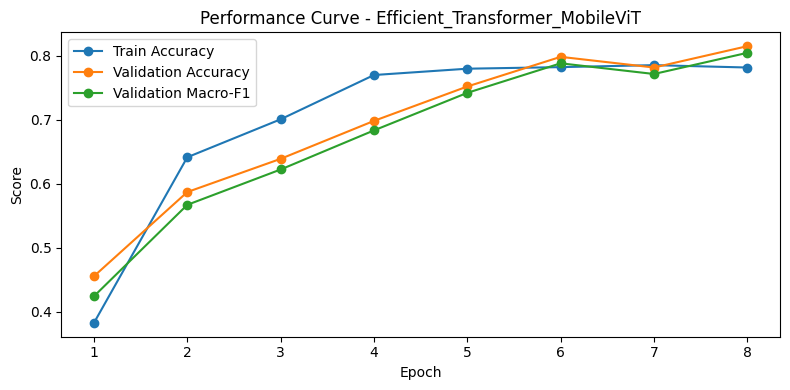

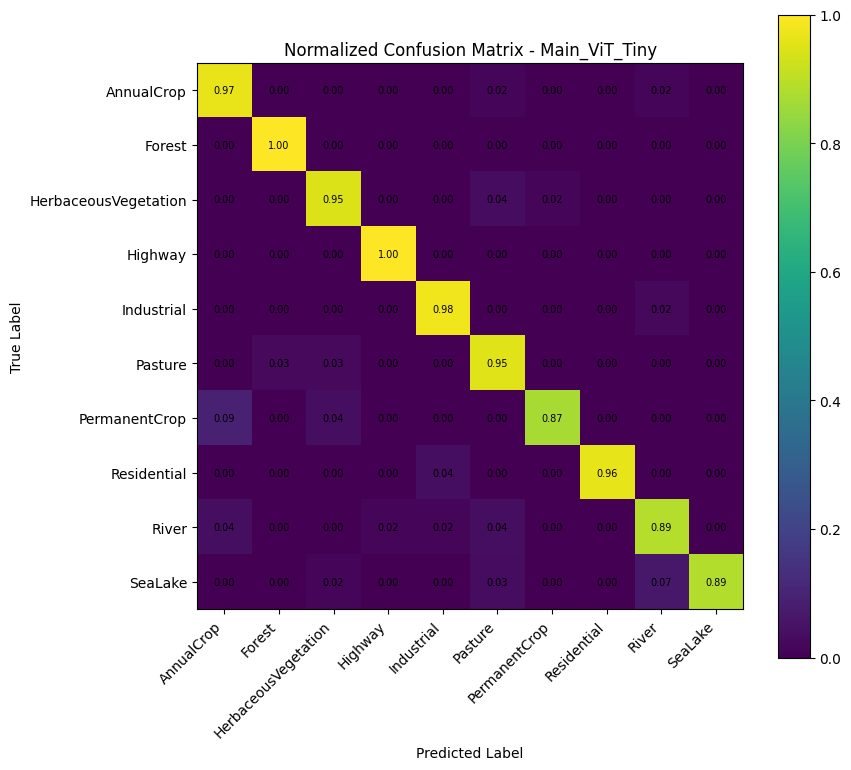

Per-Class Recall Analysis


,Class Name,Precision,Recall,F1-Score,Support
0,PermanentCrop,0.979167,0.870370,0.921569,54
1,SeaLake,1.000000,0.885246,0.939130,61
2,River,0.886792,0.886792,0.886792,53
3,HerbaceousVegetation,0.931034,0.947368,0.939130,57
4,Pasture,0.844444,0.950000,0.894118,40
5,Residential,1.000000,0.963636,0.981481,55
6,AnnualCrop,0.892308,0.966667,0.928000,60
7,Industrial,0.942308,0.980000,0.960784,50
8,Forest,0.983871,1.000000,0.991870,61
9,Highway,0.980000,1.000000,0.989899,49


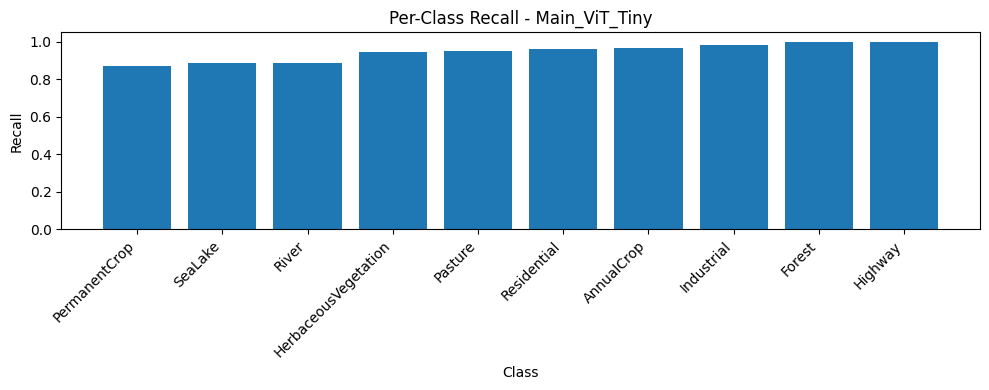

In [27]:
# 10. Learning Curves and Error Analysis Outputs
# Learning curve membantu membaca dinamika train-validation secara visual.

def plot_learning_curves(histories: Dict[str, pd.DataFrame]):
    """Membuat kurva loss dan performa untuk setiap model."""
    if not histories:
        print("Learning curves are not available because training has not been executed.")
        return

    for model_key, hist in histories.items():
        if hist.empty:
            continue

        plt.figure(figsize=(8, 4))
        plt.plot(hist["Epoch"], hist["Train Loss"], marker="o", label="Train Loss")
        plt.plot(hist["Epoch"], hist["Validation Loss"], marker="o", label="Validation Loss")
        plt.title(f"Loss Curve - {model_key}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"loss_curve_{model_key}.png", dpi=150)
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(hist["Epoch"], hist["Train Accuracy"], marker="o", label="Train Accuracy")
        plt.plot(hist["Epoch"], hist["Validation Accuracy"], marker="o", label="Validation Accuracy")
        plt.plot(hist["Epoch"], hist["Validation Macro F1"], marker="o", label="Validation Macro-F1")
        plt.title(f"Performance Curve - {model_key}")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"performance_curve_{model_key}.png", dpi=150)
        plt.show()

def plot_confusion_matrix(cm, class_names, title, filename):
    """Membuat normalized confusion matrix berbasis true label."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, np.maximum(row_sums, 1))

    plt.figure(figsize=(9, 8))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

def analyze_best_model_errors(best_model, test_artifacts):
    """Menganalisis confusion matrix dan recall per kelas dari model terbaik."""
    if best_model is None:
        print("Error analysis outputs are not available because training has not been executed.")
        return None

    key = best_model["Model Key"]
    cm = test_artifacts[key]["confusion_matrix"]

    plot_confusion_matrix(
        cm,
        label_names,
        f"Normalized Confusion Matrix - {key}",
        f"normalized_confusion_matrix_{key}.png"
    )

    per_class_df = test_artifacts[key]["report_df"].copy()
    per_class_df = per_class_df.sort_values("Recall", ascending=True).reset_index(drop=True)

    print("Per-Class Recall Analysis")
    display(per_class_df)

    plt.figure(figsize=(10, 4))
    plt.bar(per_class_df["Class Name"], per_class_df["Recall"])
    plt.title(f"Per-Class Recall - {key}")
    plt.xlabel("Class")
    plt.ylabel("Recall")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"per_class_recall_{key}.png", dpi=150)
    plt.show()

    per_class_df.to_csv(OUTPUT_DIR / f"per_class_recall_analysis_{key}.csv", index=False)
    return per_class_df

plot_learning_curves(all_histories)
best_per_class_df = analyze_best_model_errors(best_model, test_artifacts)

## 11. Explainability Output: Integrated Gradients

Cell ini menyediakan explainability menggunakan Integrated Gradients. XAI hanya dijalankan setelah model terbaik tersedia. Tujuannya bukan menggantikan metrik, melainkan memberi insight visual terhadap area citra yang memengaruhi keputusan model.

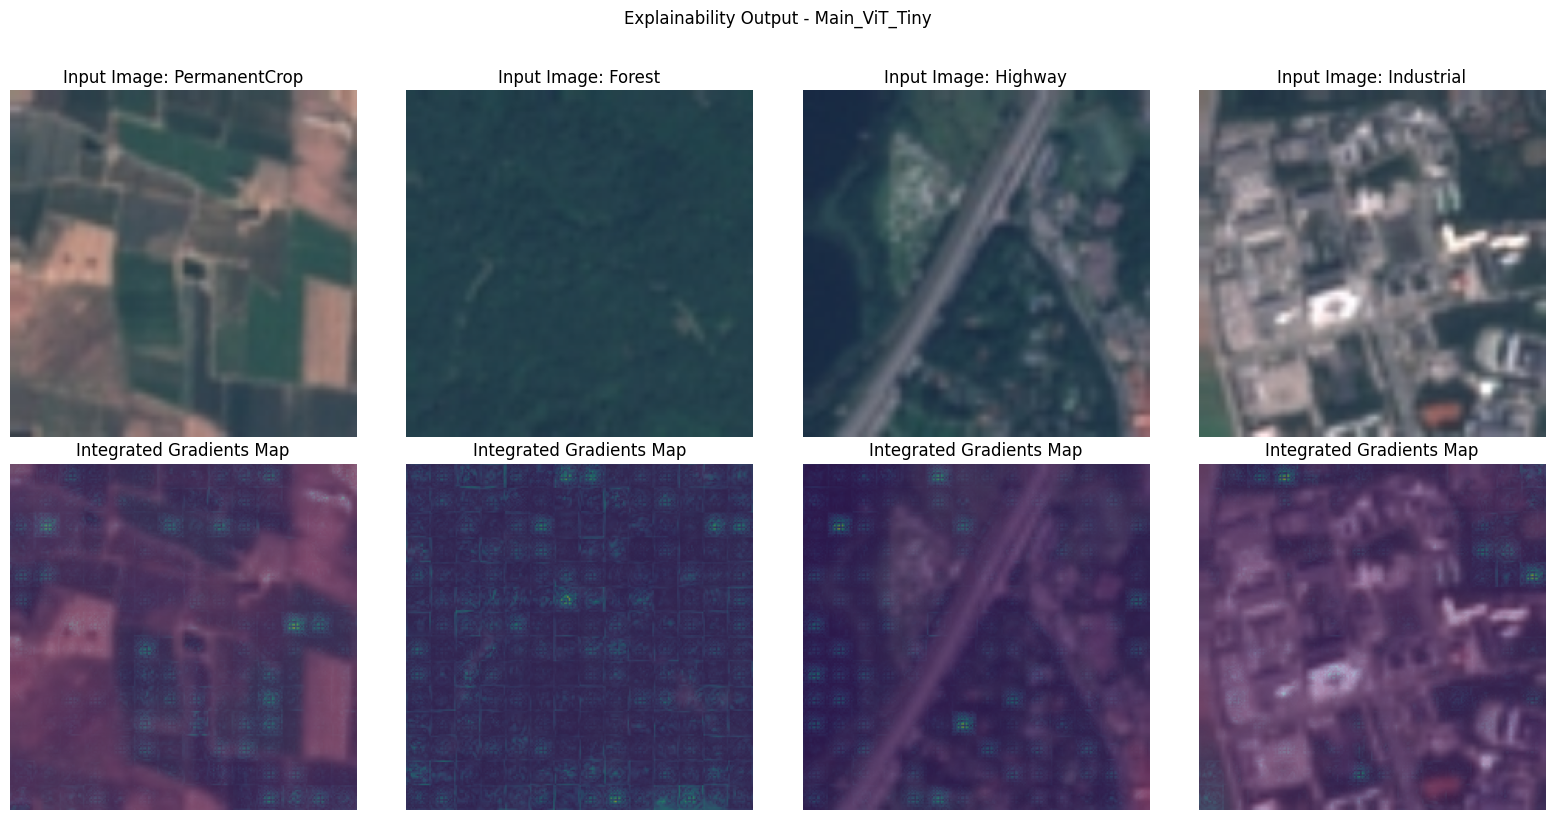

In [28]:
# 11. Explainability Output: Integrated Gradients
# XAI digunakan sebagai alat interpretasi, bukan bukti tunggal kebenaran model.

def denormalize_tensor(img_tensor):
    """Mengembalikan tensor ter-normalisasi ke rentang visual 0-1."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.detach().cpu() * std + mean
    return torch.clamp(img, 0, 1)

def run_xai_integrated_gradients(best_model, trained_models, loader, n_samples=4):
    """Menjalankan Integrated Gradients pada beberapa sampel test."""
    if best_model is None or not trained_models:
        print("Explainability output is not available because the best model has not been trained.")
        return

    try:
        from captum.attr import IntegratedGradients
    except Exception as err:
        print("Captum is not available:", err)
        return

    key = best_model["Model Key"]
    model = trained_models[key]
    model.eval()

    batch = next(iter(loader))
    x = batch["pixel_values"][:n_samples].to(DEVICE)
    y = batch["labels"][:n_samples].to(DEVICE)

    ig = IntegratedGradients(model)
    attrs = ig.attribute(x, target=y, n_steps=16)
    attrs = attrs.detach().cpu()

    plt.figure(figsize=(n_samples * 4, 8))

    for i in range(n_samples):
        img = denormalize_tensor(x[i]).permute(1, 2, 0).numpy()
        attr_map = attrs[i].abs().sum(dim=0).numpy()
        attr_map = (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min() + 1e-8)

        plt.subplot(2, n_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Input Image: {label_names[int(y[i].cpu())]}")
        plt.axis("off")

        plt.subplot(2, n_samples, n_samples + i + 1)
        plt.imshow(img)
        plt.imshow(attr_map, alpha=0.45)
        plt.title("Integrated Gradients Map")
        plt.axis("off")

    plt.suptitle(f"Explainability Output - {key}", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"integrated_gradients_output_{key}.png", dpi=150)
    plt.show()

run_xai_integrated_gradients(best_model, trained_models, test_loader, n_samples=4)

## 12. Automated Revision and Academic Report Output

Cell terakhir menyusun rekomendasi revisi otomatis berdasarkan diagnosis imbalance, underfitting, dan overfitting. Selain itu, cell ini membuat laporan ringkas bergaya akademik berdasarkan hasil aktual.

In [29]:
# 12. Automated Revision and Academic Report Output
# Laporan dibuat berdasarkan hasil yang benar-benar tersedia, bukan asumsi.

def propose_revised_config(results_df, balance_report):
    """Menyusun rekomendasi revisi konfigurasi secara otomatis."""
    revised = dict(CFG)
    actions = []

    if balance_report["Weighted Sampler Active"]:
        actions.append("WeightedRandomSampler is active because class imbalance was detected in the training split.")
    else:
        actions.append("WeightedRandomSampler is inactive because the training split is relatively balanced.")

    if balance_report["Class Weighted Loss Active"]:
        actions.append("Class-weighted loss is active to reduce potential class bias.")

    if results_df.empty:
        actions.append("No model result is available; training-based revision cannot be inferred.")
        revised["run_training"] = True
        return revised, actions

    if (results_df["Fit Status"] == "overfitting_risk").any():
        revised["weight_decay"] = min(CFG["weight_decay"] * 2, 1e-3)
        revised["early_stopping_patience"] = max(2, CFG["early_stopping_patience"] - 1)
        actions.append("Overfitting risk detected: increase weight decay and tighten early stopping.")

    if (results_df["Fit Status"] == "underfitting_risk").any():
        revised["epochs"] = CFG["epochs"] + 5
        revised["learning_rate"] = CFG["learning_rate"] * 1.5
        actions.append("Underfitting risk detected: increase epochs and tune learning rate moderately.")

    if not (results_df["Fit Status"].isin(["overfitting_risk", "underfitting_risk"])).any():
        actions.append("No critical fit issue detected; proceed with interpretation and external validation if required.")

    return revised, actions

def generate_academic_report(results_df, best_model, audit_df, balance_report, novelty_statement):
    """Membuat laporan akademik ringkas berbasis output aktual."""
    lines = []
    lines.append("# Integrated Model Evaluation Report")
    lines.append("")
    lines.append("## Dataset Audit")
    lines.append(
        f"The active dataset is derived from {CFG['dataset_name']} with subset mode = {CFG['use_subset']} "
        f"and subset fraction = {CFG['subset_fraction']:.0%}. "
        f"The detected number of classes is {num_classes}."
    )
    lines.append("")
    lines.append("## Bias and Balance Insight")
    lines.append(
        f"The training imbalance ratio is {balance_report['Train Imbalance Ratio']:.3f}. "
        f"Weighted sampler active: {balance_report['Weighted Sampler Active']}. "
        f"Class-weighted loss active: {balance_report['Class Weighted Loss Active']}."
    )
    lines.append("")
    lines.append("## Research Novelty")
    lines.append(novelty_statement)
    lines.append("")

    if results_df.empty or best_model is None:
        lines.append("## Model Evaluation Result")
        lines.append(
            "Training has not been executed. Therefore, no accuracy, macro-F1, best model, or high-performance claim is reported."
        )
    else:
        lines.append("## Model Evaluation Result")
        lines.append(
            f"The best model based on macro-F1, accuracy, parameter count, and inference time is "
            f"{best_model['Model Key']} with Test Macro-F1 = {best_model['Test Macro F1']:.4f} "
            f"and Test Accuracy = {best_model['Test Accuracy']:.4f}."
        )
        lines.append("")
        lines.append("## Interpretation Boundary")
        lines.append(
            "The conclusion is limited to the active EuroSAT RGB subset, preprocessing setting, seed, model architecture, "
            "and experimental configuration used in this notebook. If subset mode is active, full-dataset validation is required "
            "before making a final publication-level claim."
        )

    report = "\n".join(lines)
    with open(OUTPUT_DIR / "integrated_model_evaluation_report.md", "w", encoding="utf-8") as f:
        f.write(report)
    return report

revised_cfg, revision_actions = propose_revised_config(results_df, balance_report)

print("Automated Revision Recommendations")
for action in revision_actions:
    print("-", action)

with open(OUTPUT_DIR / "config_revised_recommendation.json", "w", encoding="utf-8") as f:
    json.dump(revised_cfg, f, indent=2, ensure_ascii=False)

report_text = generate_academic_report(
    results_df=results_df,
    best_model=best_model,
    audit_df=audit_df,
    balance_report=balance_report,
    novelty_statement=novelty_statement
)

print("\nIntegrated Model Evaluation Report")
print(report_text)

print("\nGenerated Output Files")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Automated Revision Recommendations
- WeightedRandomSampler is active because class imbalance was detected in the training split.
- Class-weighted loss is active to reduce potential class bias.
- Underfitting risk detected: increase epochs and tune learning rate moderately.

Integrated Model Evaluation Report
# Integrated Model Evaluation Report

## Dataset Audit
The active dataset is derived from timm/eurosat-rgb with subset mode = True and subset fraction = 10%. The detected number of classes is 10.

## Bias and Balance Insight
The training imbalance ratio is 1.550. Weighted sampler active: True. Class-weighted loss active: True.

## Research Novelty
Novelty: an integrated evaluation pipeline for EuroSAT RGB classification that combines data bias auditing, stratified 10% subset sampling, reproducibility control, CNN baseline, pretrained Vision Transformer, efficient Transformer, macro-F1, confusion matrix, computational efficiency analysis, and explainability.

## Model Evaluation Res

## 13. Research Discussion and Step-by-Step Logical Validation

Tahap ini menambahkan pembahasan logis setelah pipeline utama. Fokusnya adalah memastikan seluruh proses mengikuti standar *machine learning/data mining/data science workflow*: audit dataset, EDA, preprocessing, balancing, training, evaluasi, pemilihan model, penyimpanan model, uji inferensi sederhana, dan deployment dashboard.

**Insight akademik:** model terbaik tidak boleh dipilih hanya dari accuracy. Notebook ini memakai urutan prioritas yang konsisten: macro-F1, accuracy, jumlah parameter, dan waktu inferensi. Jika terjadi kesalahan, perbaikan harus mengikuti sumber masalah: data, transformasi, model, device, file path, atau dependency deployment.

In [30]:
# 13. Research Discussion and Step-by-Step Logical Validation
# Cell ini membuat struktur folder artefak agar seluruh output berada dalam satu folder utama.

MODELS_DIR = OUTPUT_DIR / "models"
APP_DIR = OUTPUT_DIR / "streamlit_app"
DEPLOYMENT_TEST_DIR = OUTPUT_DIR / "deployment_test_samples"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [MODELS_DIR, APP_DIR, DEPLOYMENT_TEST_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

research_workflow = pd.DataFrame([
    {
        "Step": "1. Dataset Loading and Caching",
        "Logical Purpose": "Memastikan dataset dimuat sekali, disimpan, dan dapat digunakan ulang dari cache lokal.",
        "Integrity Check": "Tidak mengunduh dan memproses dataset berulang-ulang."
    },
    {
        "Step": "2. Data Audit and EDA",
        "Logical Purpose": "Mengidentifikasi distribusi kelas, contoh citra, dan profil RGB.",
        "Integrity Check": "Tidak langsung training sebelum karakter data diperiksa."
    },
    {
        "Step": "3. Bias and Balance Control",
        "Logical Purpose": "Mengurangi risiko dominasi kelas tertentu.",
        "Integrity Check": "Weighted sampler dan class-weighted loss hanya digunakan jika relevan."
    },
    {
        "Step": "4. Model Training",
        "Logical Purpose": "Melatih CNN baseline, ViT, dan Transformer efisien secara adil.",
        "Integrity Check": "Semua model memakai split, preprocessing, dan metrik yang sama."
    },
    {
        "Step": "5. Model Evaluation",
        "Logical Purpose": "Mengukur accuracy, macro-F1, recall, confusion matrix, dan efisiensi.",
        "Integrity Check": "Test set hanya digunakan setelah model selesai dipilih."
    },
    {
        "Step": "6. Model Persistence",
        "Logical Purpose": "Menyimpan model terbaik untuk reproduksi dan deployment.",
        "Integrity Check": "Menyimpan checkpoint PyTorch dan bundle joblib beserta metadata."
    },
    {
        "Step": "7. Deployment Smoke Test",
        "Logical Purpose": "Menguji model pada 7 citra unseen dari test split sebagai simulasi inferensi.",
        "Integrity Check": "Tidak mengklaim generalisasi eksternal jika belum memakai data baru di luar dataset."
    },
    {
        "Step": "8. Streamlit Dashboard",
        "Logical Purpose": "Membuat aplikasi interaktif untuk upload citra dan prediksi kelas.",
        "Integrity Check": "Token ngrok dimasukkan manual melalui getpass agar tidak tampil di output."
    }
])

print("Research Workflow Validation Table")
display(research_workflow)

research_workflow.to_csv(REPORT_DIR / "research_workflow_validation_table.csv", index=False)

Research Workflow Validation Table


,Step,Logical Purpose,Integrity Check
0,1. Dataset Loading and Caching,"Memastikan dataset dimuat sekali, disimpan, dan dapat digunakan ulang dari cache lokal.",Tidak mengunduh dan memproses dataset berulang-ulang.
1,2. Data Audit and EDA,"Mengidentifikasi distribusi kelas, contoh citra, dan profil RGB.",Tidak langsung training sebelum karakter data diperiksa.
2,3. Bias and Balance Control,Mengurangi risiko dominasi kelas tertentu.,Weighted sampler dan class-weighted loss hanya digunakan jika relevan.
3,4. Model Training,"Melatih CNN baseline, ViT, dan Transformer efisien secara adil.","Semua model memakai split, preprocessing, dan metrik yang sama."
4,5. Model Evaluation,"Mengukur accuracy, macro-F1, recall, confusion matrix, dan efisiensi.",Test set hanya digunakan setelah model selesai dipilih.
5,6. Model Persistence,Menyimpan model terbaik untuk reproduksi dan deployment.,Menyimpan checkpoint PyTorch dan bundle joblib beserta metadata.
6,7. Deployment Smoke Test,Menguji model pada 7 citra unseen dari test split sebagai simulasi inferensi.,Tidak mengklaim generalisasi eksternal jika belum memakai data baru di luar dataset.
7,8. Streamlit Dashboard,Membuat aplikasi interaktif untuk upload citra dan prediksi kelas.,Token ngrok dimasukkan manual melalui getpass agar tidak tampil di output.


## 14. Error Handling Matrix and Logical Revision Rules

Bagian ini mendokumentasikan potensi kesalahan dan aturan perbaikan. Tujuannya agar proses debugging tidak dilakukan secara acak, tetapi mengikuti logika penyebab masalah.

In [31]:
# 14. Error Handling Matrix and Logical Revision Rules
# Matriks ini membantu peneliti melakukan debugging secara sistematis.

error_handling_matrix = pd.DataFrame([
    {
        "Potential Error": "Dataset cache is not found",
        "Likely Cause": "Notebook dijalankan pertama kali atau folder cache terhapus.",
        "Logical Fix": "Jalankan ulang cell dataset loading; program akan mengunduh dan menyimpan cache baru."
    },
    {
        "Potential Error": "Class imbalance is detected",
        "Likely Cause": "Distribusi kelas subset atau split tidak proporsional.",
        "Logical Fix": "Gunakan stratified sampling, WeightedRandomSampler, dan class-weighted loss."
    },
    {
        "Potential Error": "CUDA out of memory",
        "Likely Cause": "Batch size terlalu besar atau model terlalu berat.",
        "Logical Fix": "Turunkan batch_size, gunakan subset 10%, atau prioritaskan model efisien."
    },
    {
        "Potential Error": "Tensor shape mismatch",
        "Likely Cause": "Transformasi citra tidak menghasilkan format [B, C, H, W].",
        "Logical Fix": "Periksa collate_fn dan pastikan citra dikonversi ke RGB serta ToTensor."
    },
    {
        "Potential Error": "Classifier output does not match class count",
        "Likely Cause": "Classifier head model belum disesuaikan.",
        "Logical Fix": "Gunakan timm.create_model(..., num_classes=num_classes)."
    },
    {
        "Potential Error": "Overfitting risk",
        "Likely Cause": "Train accuracy jauh lebih tinggi daripada validation accuracy.",
        "Logical Fix": "Gunakan early stopping, weight decay, augmentasi, dan kurangi epoch."
    },
    {
        "Potential Error": "Underfitting risk",
        "Likely Cause": "Train dan validation score sama-sama rendah.",
        "Logical Fix": "Tambah epoch secara moderat, tuning learning rate, atau cek preprocessing."
    },
    {
        "Potential Error": "Deployment model cannot be loaded",
        "Likely Cause": "Path model salah atau bundle joblib belum dibuat.",
        "Logical Fix": "Jalankan cell model persistence setelah training selesai."
    },
    {
        "Potential Error": "ngrok token is exposed",
        "Likely Cause": "Token ditulis langsung dalam cell.",
        "Logical Fix": "Gunakan getpass.getpass agar token tidak tercetak."
    }
])

print("Error Handling and Logical Revision Matrix")
display(error_handling_matrix)

error_handling_matrix.to_csv(REPORT_DIR / "error_handling_and_revision_matrix.csv", index=False)

Error Handling and Logical Revision Matrix


,Potential Error,Likely Cause,Logical Fix
0,Dataset cache is not found,Notebook dijalankan pertama kali atau folder cache terhapus.,Jalankan ulang cell dataset loading; program akan mengunduh dan menyimpan cache baru.
1,Class imbalance is detected,Distribusi kelas subset atau split tidak proporsional.,"Gunakan stratified sampling, WeightedRandomSampler, dan class-weighted loss."
2,CUDA out of memory,Batch size terlalu besar atau model terlalu berat.,"Turunkan batch_size, gunakan subset 10%, atau prioritaskan model efisien."
3,Tensor shape mismatch,"Transformasi citra tidak menghasilkan format [B, C, H, W].",Periksa collate_fn dan pastikan citra dikonversi ke RGB serta ToTensor.
4,Classifier output does not match class count,Classifier head model belum disesuaikan.,"Gunakan timm.create_model(..., num_classes=num_classes)."
5,Overfitting risk,Train accuracy jauh lebih tinggi daripada validation accuracy.,"Gunakan early stopping, weight decay, augmentasi, dan kurangi epoch."
6,Underfitting risk,Train dan validation score sama-sama rendah.,"Tambah epoch secara moderat, tuning learning rate, atau cek preprocessing."
7,Deployment model cannot be loaded,Path model salah atau bundle joblib belum dibuat.,Jalankan cell model persistence setelah training selesai.
8,ngrok token is exposed,Token ditulis langsung dalam cell.,Gunakan getpass.getpass agar token tidak tercetak.


## 15. Model Persistence: PyTorch Checkpoint and Joblib Bundle

Cell ini menyimpan model terbaik dalam dua bentuk:

1. **PyTorch checkpoint (`.pth`)** untuk praktik standar penyimpanan bobot model.
2. **Joblib bundle (`.joblib`)** untuk menyimpan metadata, konfigurasi, nama kelas, dan `state_dict` model.

Catatan integritas: `joblib.load` berbasis pickle, sehingga file joblib hanya boleh dimuat dari sumber yang benar-benar tepercaya.

In [32]:
# 15. Model Persistence: PyTorch Checkpoint and Joblib Bundle
# Model hanya disimpan jika training sudah dijalankan dan model terbaik tersedia.

import joblib

def save_best_model_artifacts(best_model, trained_models, results_df):
    """
    Menyimpan model terbaik beserta metadata.
    Jika training belum dijalankan, fungsi tidak membuat model palsu.
    """
    if best_model is None or not trained_models:
        print("Model persistence skipped: training has not been executed or best model is unavailable.")
        print("Set CFG['run_training'] = True, run training, then execute this cell again.")
        return None

    model_key = best_model["Model Key"]
    model_name = best_model["Model Name"]
    model = trained_models[model_key]
    model.eval()

    # State dictionary dipindahkan ke CPU agar lebih mudah dipakai lintas device.
    state_dict_cpu = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    checkpoint = {
        "program_title": CFG["program_title"],
        "model_key": model_key,
        "model_name": model_name,
        "num_classes": num_classes,
        "class_names": label_names,
        "image_size": CFG["image_size"],
        "normalization_mean": [0.485, 0.456, 0.406],
        "normalization_std": [0.229, 0.224, 0.225],
        "state_dict": state_dict_cpu,
        "best_model_metrics": best_model,
        "config": CFG,
        "created_at": datetime.datetime.now().isoformat()
    }

    torch_checkpoint_path = MODELS_DIR / "best_model_checkpoint.pth"
    joblib_bundle_path = MODELS_DIR / "best_model_bundle.joblib"
    metrics_path = MODELS_DIR / "best_model_metrics.csv"

    torch.save(checkpoint, torch_checkpoint_path)
    joblib.dump(checkpoint, joblib_bundle_path, compress=3)
    pd.DataFrame([best_model]).to_csv(metrics_path, index=False)

    saved_files = {
        "Torch Checkpoint": str(torch_checkpoint_path),
        "Joblib Bundle": str(joblib_bundle_path),
        "Metrics CSV": str(metrics_path)
    }

    print("Best Model Persistence Summary")
    display(pd.DataFrame([saved_files]))

    return saved_files

saved_model_files = save_best_model_artifacts(best_model, trained_models, results_df)

Best Model Persistence Summary


,Torch Checkpoint,Joblib Bundle,Metrics CSV
0,eurosat_vit_academic_outputs/models/best_model_checkpoint.pth,eurosat_vit_academic_outputs/models/best_model_bundle.joblib,eurosat_vit_academic_outputs/models/best_model_metrics.csv


## 16. Deployment Smoke Test on 7 Unseen Images

Cell ini melakukan pengujian sederhana pada 7 citra dari test split. Secara metodologis, ini adalah **unseen test samples**, bukan data eksternal baru. Untuk klaim deployment final, pengguna perlu menguji citra satelit baru dari luar dataset.

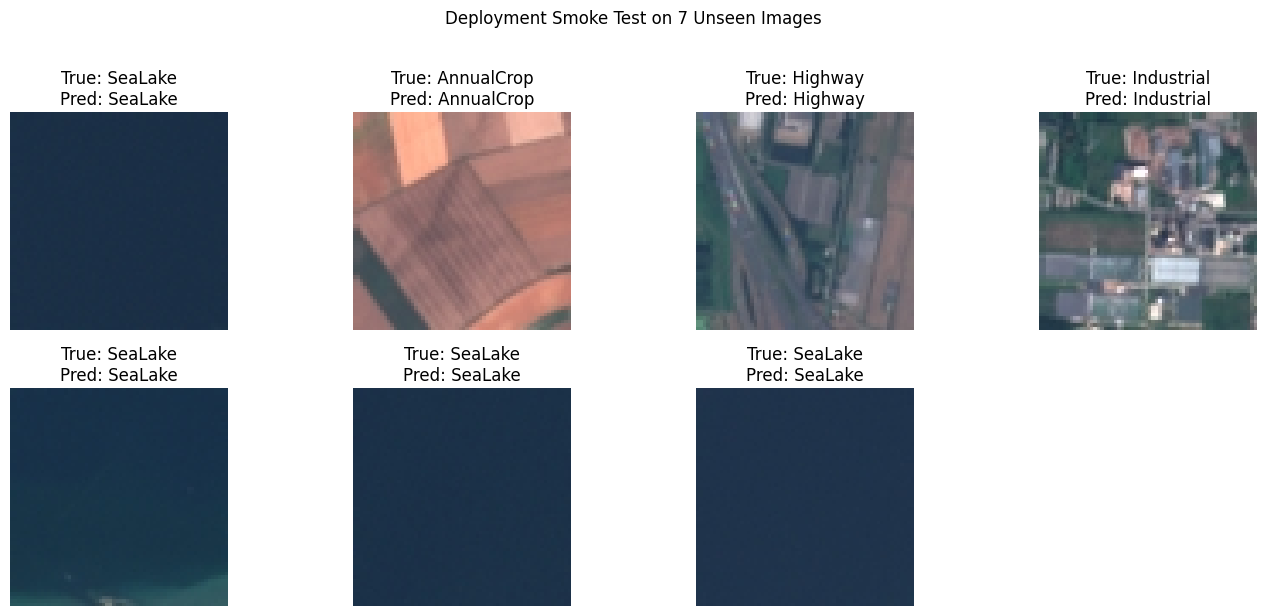

Deployment Smoke Test Results


,Sample No,Image Path,True Class,Predicted Class,Confidence,Correct,Top-3 Prediction
0,1,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_1_true_SeaLake.png,SeaLake,SeaLake,0.954951,True,"[(SeaLake, 0.954951286315918), (Forest, 0.009812820702791214), (Residential, 0.0062265945598483086)]"
1,2,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_2_true_AnnualCrop.png,AnnualCrop,AnnualCrop,0.963776,True,"[(AnnualCrop, 0.9637762308120728), (HerbaceousVegetation, 0.008563418872654438), (Industrial, 0.005068166647106409)]"
2,3,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_3_true_Highway.png,Highway,Highway,0.895631,True,"[(Highway, 0.8956307172775269), (Industrial, 0.03892259672284126), (River, 0.025671053677797318)]"
3,4,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_4_true_Industrial.png,Industrial,Industrial,0.861006,True,"[(Industrial, 0.861006498336792), (SeaLake, 0.05236504226922989), (PermanentCrop, 0.03416833654046059)]"
4,5,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_5_true_SeaLake.png,SeaLake,SeaLake,0.872916,True,"[(SeaLake, 0.872916042804718), (Forest, 0.05649944767355919), (Highway, 0.019348086789250374)]"
5,6,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_6_true_SeaLake.png,SeaLake,SeaLake,0.954075,True,"[(SeaLake, 0.9540748596191406), (Forest, 0.00990714505314827), (Residential, 0.006805427372455597)]"
6,7,eurosat_vit_academic_outputs/deployment_test_samples/smoke_test_sample_7_true_SeaLake.png,SeaLake,SeaLake,0.960076,True,"[(SeaLake, 0.9600763916969299), (Forest, 0.010165421292185783), (Residential, 0.006929763592779636)]"


In [33]:
# 16. Deployment Smoke Test on 7 Unseen Images
# Pengujian ini memastikan model dapat melakukan inferensi end-to-end pada sampel test.

def predict_single_pil_image(model, pil_image):
    """Melakukan prediksi pada satu citra PIL."""
    model.eval()
    x = eval_transform(pil_image.convert("RGB")).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])
    top3_idx = probs.argsort()[-3:][::-1]

    return {
        "Predicted Label ID": pred_idx,
        "Predicted Class": label_names[pred_idx],
        "Confidence": confidence,
        "Top-3 Prediction": [(label_names[int(i)], float(probs[int(i)])) for i in top3_idx]
    }

def run_deployment_smoke_test(best_model, trained_models, n_samples=7):
    """
    Menguji model pada 7 citra dari test split.
    Jika training belum dijalankan, fungsi tidak membuat output prediksi palsu.
    """
    if best_model is None or not trained_models:
        print("Deployment smoke test skipped: training has not been executed or best model is unavailable.")
        return pd.DataFrame()

    model_key = best_model["Model Key"]
    model = trained_models[model_key]

    test_raw = ds_work["test"]
    rng = np.random.default_rng(CFG["seed"])
    sample_indices = rng.choice(len(test_raw), size=min(n_samples, len(test_raw)), replace=False)

    records = []

    plt.figure(figsize=(14, 6))
    for plot_i, idx in enumerate(sample_indices):
        item = test_raw[int(idx)]
        image = item["image"].convert("RGB")
        true_label_id = int(item["label"])
        true_class = label_names[true_label_id]

        pred = predict_single_pil_image(model, image)

        safe_true_class = true_class.replace("/", "_").replace(" ", "_")
        file_path = DEPLOYMENT_TEST_DIR / f"smoke_test_sample_{plot_i+1}_true_{safe_true_class}.png"
        image.save(file_path)

        records.append({
            "Sample No": plot_i + 1,
            "Image Path": str(file_path),
            "True Class": true_class,
            "Predicted Class": pred["Predicted Class"],
            "Confidence": pred["Confidence"],
            "Correct": true_class == pred["Predicted Class"],
            "Top-3 Prediction": pred["Top-3 Prediction"]
        })

        plt.subplot(2, math.ceil(len(sample_indices) / 2), plot_i + 1)
        plt.imshow(image)
        plt.title(f"True: {true_class}\nPred: {pred['Predicted Class']}")
        plt.axis("off")

    plt.suptitle("Deployment Smoke Test on 7 Unseen Images", y=1.02)
    plt.tight_layout()
    plt.savefig(DEPLOYMENT_TEST_DIR / "deployment_smoke_test_grid.png", dpi=150)
    plt.show()

    smoke_test_df = pd.DataFrame(records)
    smoke_test_df.to_csv(DEPLOYMENT_TEST_DIR / "deployment_smoke_test_results.csv", index=False)

    print("Deployment Smoke Test Results")
    display(smoke_test_df)

    return smoke_test_df

deployment_smoke_test_df = run_deployment_smoke_test(best_model, trained_models, n_samples=7)

## 17. Streamlit Application Builder

Cell ini membuat file aplikasi Streamlit dalam folder output. Aplikasi memuat `best_model_bundle.joblib`, menerima upload citra, lalu menampilkan prediksi kelas dan confidence score.

Catatan: aplikasi hanya dapat berjalan setelah model terbaik disimpan.

In [34]:
# 17. Streamlit Application Builder
# Aplikasi ditulis sebagai file app.py agar dapat dijalankan dari Colab menggunakan Streamlit + ngrok.

APP_DIR.mkdir(parents=True, exist_ok=True)

streamlit_app_code = """
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import timm
import streamlit as st
from torchvision import transforms

st.set_page_config(
    page_title="EuroSAT RGB Land Use/Land Cover Classifier",
    page_icon="🛰️",
    layout="wide"
)

st.title("EuroSAT RGB Land Use/Land Cover Classifier")
st.caption("Interactive Vision Transformer-based inference dashboard")

ARTIFACT_DIR = Path("eurosat_vit_academic_outputs")
MODEL_BUNDLE_PATH = ARTIFACT_DIR / "models" / "best_model_bundle.joblib"

@st.cache_resource
def load_model_bundle():
    # Catatan akademik: joblib.load hanya boleh digunakan pada file tepercaya.
    if not MODEL_BUNDLE_PATH.exists():
        return None, f"Model bundle not found: {MODEL_BUNDLE_PATH}"

    bundle = joblib.load(MODEL_BUNDLE_PATH)

    model = timm.create_model(
        bundle["model_name"],
        pretrained=False,
        num_classes=bundle["num_classes"]
    )
    model.load_state_dict(bundle["state_dict"])
    model.eval()

    return {
        "model": model,
        "class_names": bundle["class_names"],
        "image_size": bundle["image_size"],
        "mean": bundle["normalization_mean"],
        "std": bundle["normalization_std"],
        "metrics": bundle.get("best_model_metrics", {})
    }, None

bundle, error = load_model_bundle()

if error:
    st.error(error)
    st.info("Run training and model persistence cells first before launching this app.")
    st.stop()

model = bundle["model"]
class_names = bundle["class_names"]

preprocess = transforms.Compose([
    transforms.Resize((bundle["image_size"], bundle["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=bundle["mean"], std=bundle["std"]),
])

st.sidebar.header("Model Information")
st.sidebar.write("Model name:", bundle["metrics"].get("Model Name", "N/A"))
st.sidebar.write("Model key:", bundle["metrics"].get("Model Key", "N/A"))
st.sidebar.write("Subset-based experiment:", "Yes")
st.sidebar.warning(
    "This dashboard is for research prototyping. "
    "For publication-level claims, validate on the full dataset and external images."
)

uploaded_file = st.file_uploader(
    "Upload a satellite image",
    type=["png", "jpg", "jpeg"]
)

def predict_image(image):
    x = preprocess(image.convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    prob_df = pd.DataFrame({
        "Class": class_names,
        "Probability": probs
    }).sort_values("Probability", ascending=False)

    return pred_class, confidence, prob_df

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("Input Image")
        st.image(image, use_container_width=True)

    with col2:
        pred_class, confidence, prob_df = predict_image(image)
        st.subheader("Prediction Result")
        st.metric("Predicted Class", pred_class)
        st.metric("Confidence", f"{confidence:.4f}")

        st.subheader("Top Class Probabilities")
        st.dataframe(prob_df.head(10), use_container_width=True)
        st.bar_chart(prob_df.set_index("Class")["Probability"])
else:
    st.info("Upload one RGB satellite image to run inference.")
"""

streamlit_app_path = APP_DIR / "app.py"
streamlit_app_path.write_text(streamlit_app_code, encoding="utf-8")

print("Streamlit Application File")
print(streamlit_app_path)

Streamlit Application File
eurosat_vit_academic_outputs/streamlit_app/app.py


## 18. Run Streamlit Dashboard in Google Colab with Hidden ngrok Token

Cell ini menjalankan Streamlit dari Google Colab. Token ngrok dimasukkan manual melalui `getpass`, sehingga tidak tampil di output notebook.

Catatan keamanan: jangan menulis token ngrok langsung di cell.

In [37]:
# 18. Run Streamlit Dashboard in Google Colab with Hidden ngrok Token
# Jalankan cell ini hanya setelah model bundle tersedia dan app.py telah dibuat.

from getpass import getpass
from pyngrok import ngrok

def launch_streamlit_with_ngrok():
    """
    Menjalankan Streamlit dan membuka tunnel ngrok.
    Token dimasukkan manual dan disembunyikan oleh getpass.
    """
    model_bundle_path = MODELS_DIR / "best_model_bundle.joblib"
    app_path = APP_DIR / "app.py"

    if not model_bundle_path.exists():
        print("Cannot launch dashboard: best_model_bundle.joblib does not exist.")
        print("Run training and model persistence cells first.")
        return None

    if not app_path.exists():
        print("Cannot launch dashboard: Streamlit app.py does not exist.")
        print("Run the Streamlit Application Builder cell first.")
        return None

    token = getpass("Enter ngrok authtoken (hidden input): ")
    ngrok.set_auth_token(token)

    # Menutup tunnel lama agar tidak terjadi konflik port.
    try:
        ngrok.kill()
    except Exception:
        pass

    log_path = APP_DIR / "streamlit_runtime.log"
    log_file = open(log_path, "w", encoding="utf-8")

    # Streamlit dijalankan sebagai proses latar di Colab.
    process = subprocess.Popen(
        ["streamlit", "run", str(app_path), "--server.port", "8501", "--server.address", "0.0.0.0"],
        stdout=log_file,
        stderr=subprocess.STDOUT
    )

    time.sleep(5)
    public_url = ngrok.connect(8501)

    print("Streamlit Public URL")
    print(public_url)
    print("Runtime log:", log_path)
    return public_url

# Untuk menjalankan dashboard, hapus komentar pada baris berikut:
public_url = launch_streamlit_with_ngrok()

Enter ngrok authtoken (hidden input): ··········
Streamlit Public URL
NgrokTunnel: "https://edginess-reunion-marshland.ngrok-free.dev" -> "http://localhost:8501"
Runtime log: eurosat_vit_academic_outputs/streamlit_app/streamlit_runtime.log


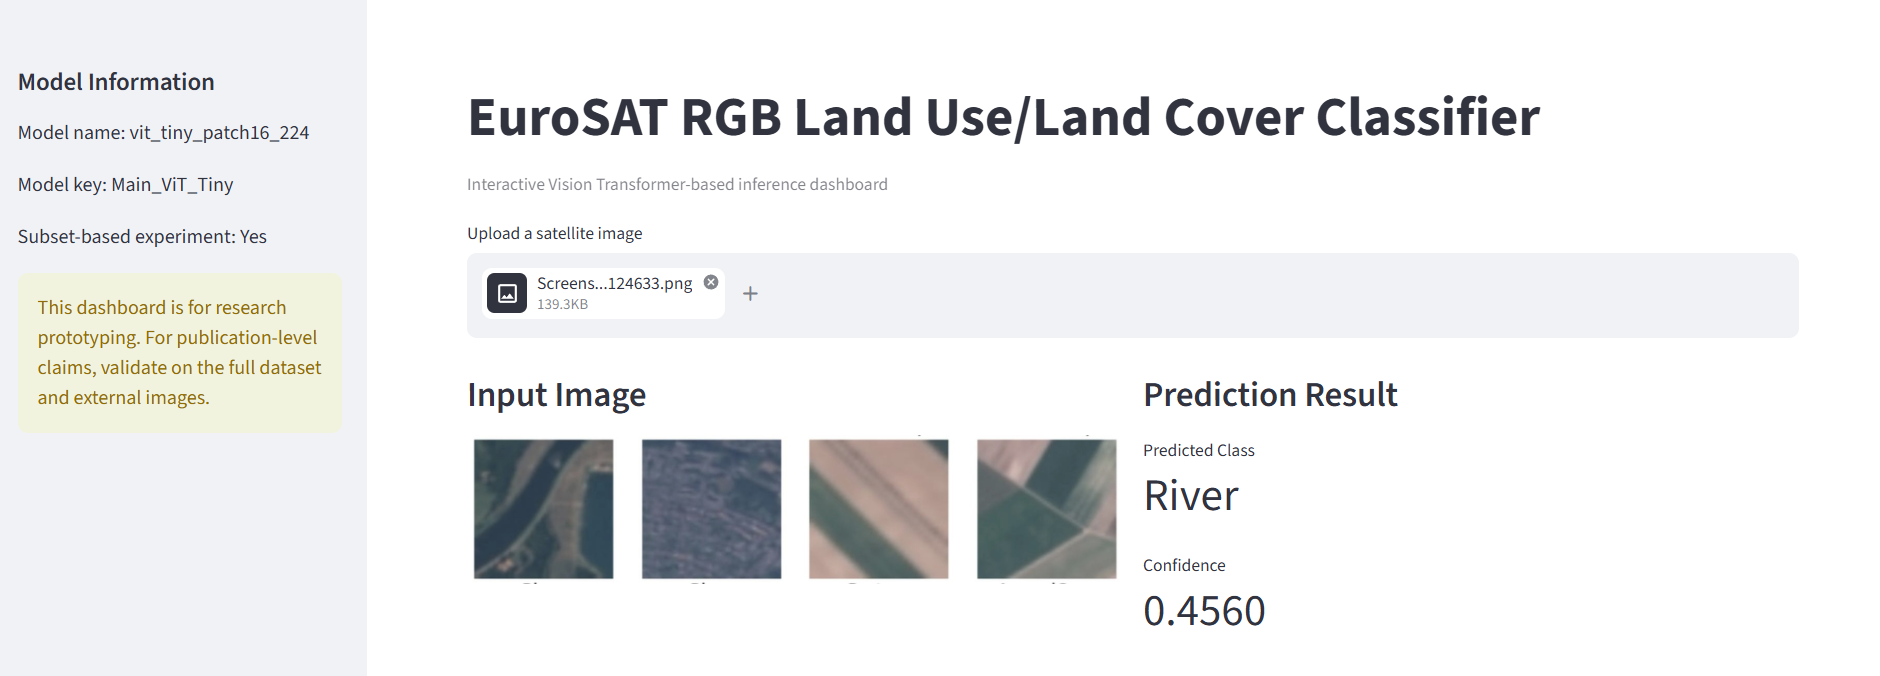

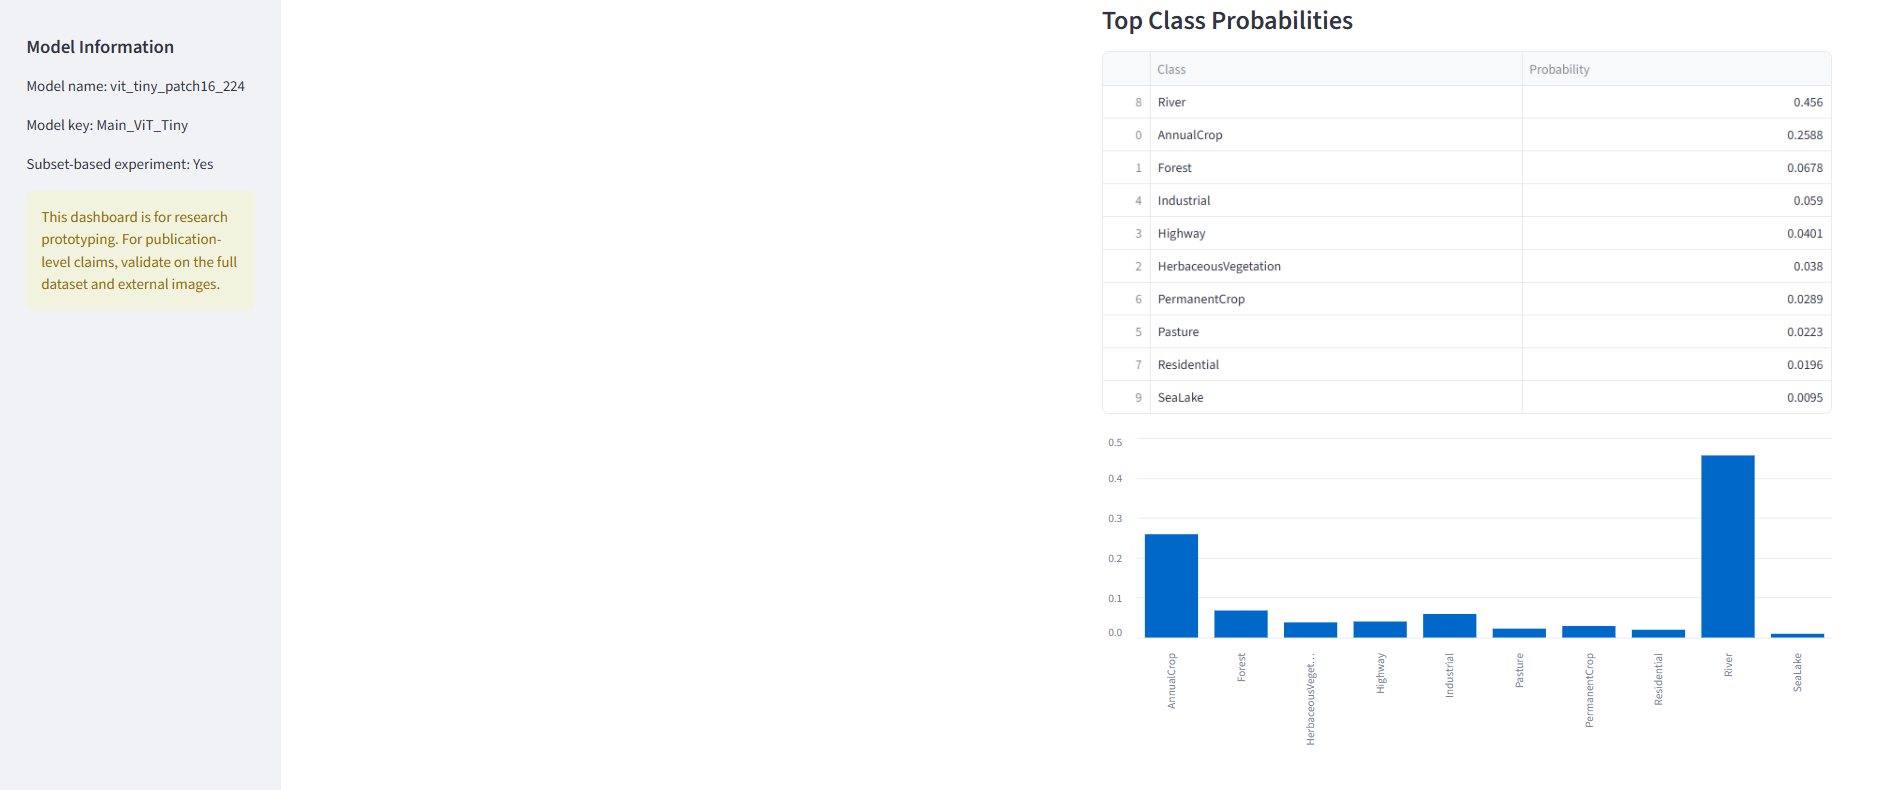

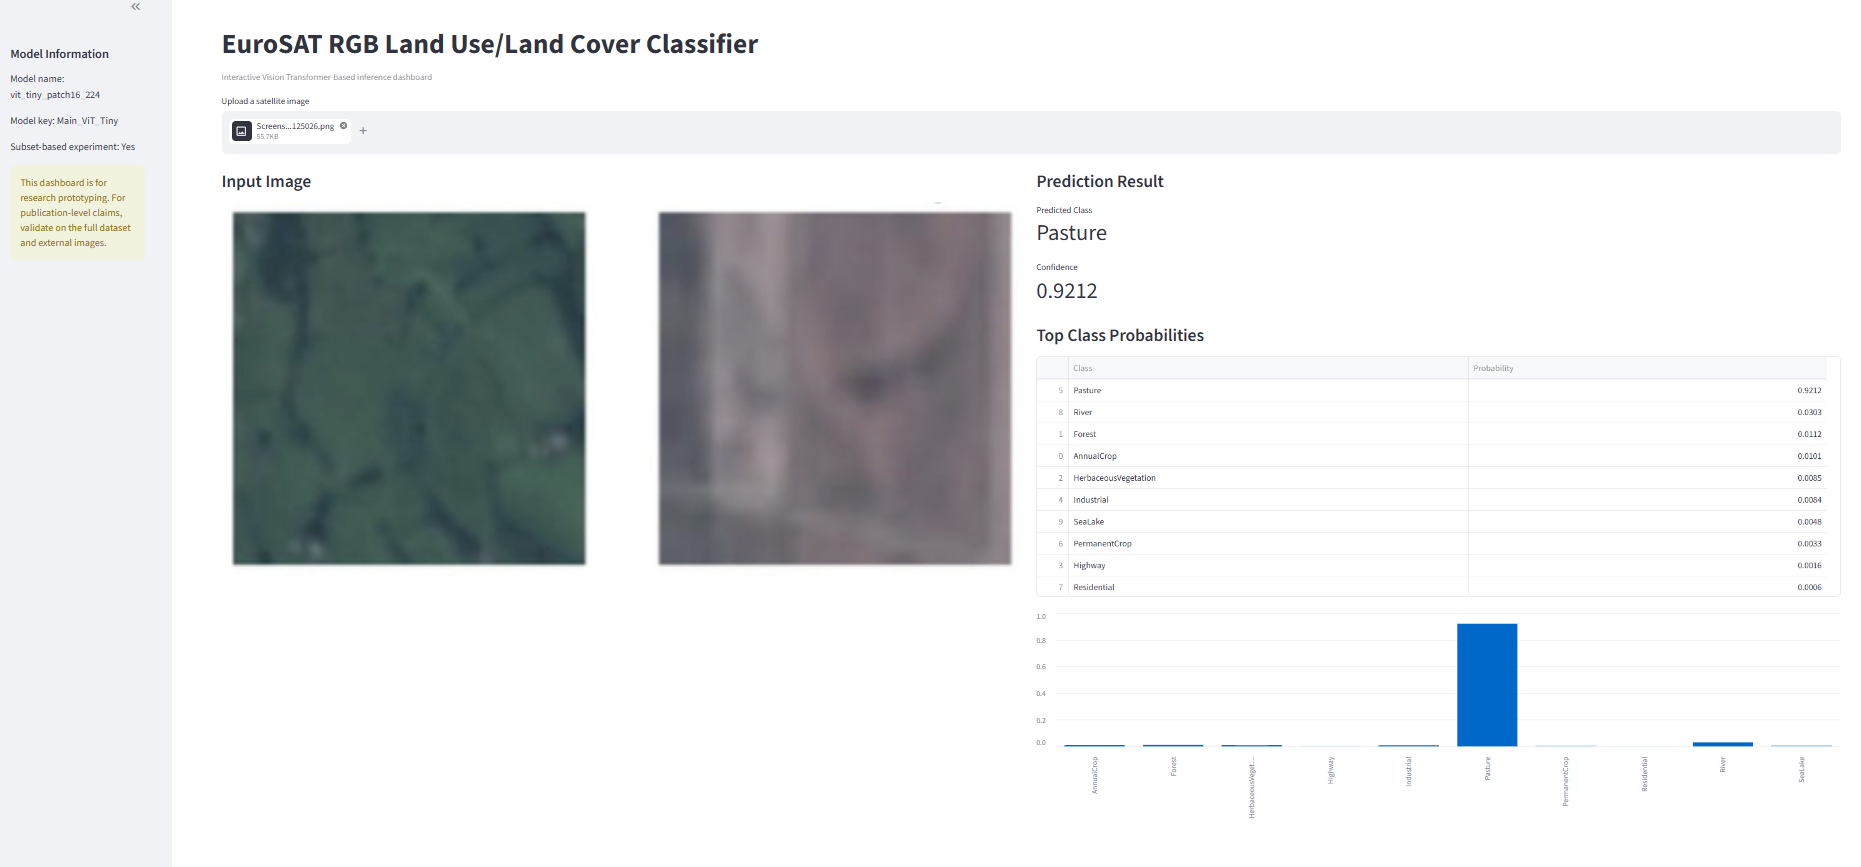